# Tutorial 1: ChemEv Modeling of Bootes I
Author: Nathan Sandford

In this tutorial, we will implement apply several galactic chemical evolution models of varying complexity to explore the evolution of a Milky Way satellite galaxy, Bootes I (Boo I).


For both tutorials, you will need the following packages installed in your Python environment:
- numpy
- pandas
- scipy
- astropy
- tables
- matplotlib
- corner
- pocomc
- multiprocess

To install these, you can run the cell below.

You will also need the code provided in the `waf` directory. This code is a simplified version of the [`ChemWAF`](https://github.com/NathanSandford/ChemWAF) package, which wraps the model of [Weinberg, Andrews, and Freudenburg (2017)](https://ui.adsabs.harvard.edu/abs/2017ApJ...837..183W/abstract).

In [ ]:
!pip install numpy pandas scipy astropy tables matplotlib corner pocomc multiprocess

# Imports

In [1]:
import numpy as np
import pandas as pd
from astropy.table import Table
from scipy.ndimage import gaussian_filter1d

from waf.models import waf2017
from waf.par import DefaultParSet
from waf.utils import get_PDF, get_MDF, randdist
from waf.priors import UniformLogPrior, GaussianLogPrior

import multiprocess as mp
import pocomc as pc

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from corner import corner

"""
Ignore Numpy errors
"""
np.seterr(all="ignore")


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

# Loading the data

First, we will load the data for Boo I from [Sandford et al. (2026)](https://ui.adsabs.harvard.edu/abs/2026ApJ...998...47S/abstract). The data contains the measurements and measurement uncertainties of [Fe/H] for high probability member stars of Boo I. For your AST1420 project, you will need to find similar measurements for your dwarf galaxy.  

In [2]:
# Load All BooI Data
all_boo1_df = Table.read("./BooI_final_catalog.ecsv").to_pandas()

# Select Members w/ Good [Fe/H] Measurements
boo1_df = all_boo1_df.loc[
    (all_boo1_df["member"] == True) 
    & (all_boo1_df["feh_avg"].notna()) 
    & (all_boo1_df["feh_err_avg"].notna()) 
]

# Renaming columns to avoid refactoring of the code below. 
boo1_df.rename(
    columns={"feh_avg": "FeH", "feh_err_avg": "FeH_err"}, 
    inplace=True
)

# Preview DataFrame
boo1_df[["FeH", "FeH_err"]]

,FeH,FeH_err
0,-2.78,0.09
1,-2.54,0.08
2,-2.44,0.09
3,-2.85,0.04
4,-2.20,0.04
...,...,...
147,-2.48,0.93
148,-2.93,0.38
150,-2.02,0.38
151,-2.05,0.37


# Observed Metallicity Distribution Function

Let's see what the metallicity distribution function (MDF) of Boo I looks like. We'll plot both the MDF as well as the cummulative MDF (CMDF). It will be immediately apparent that the mean of Boo I's MDF is at much lower metallicities than the MDF for the Milky Way discussed in the textbook.  

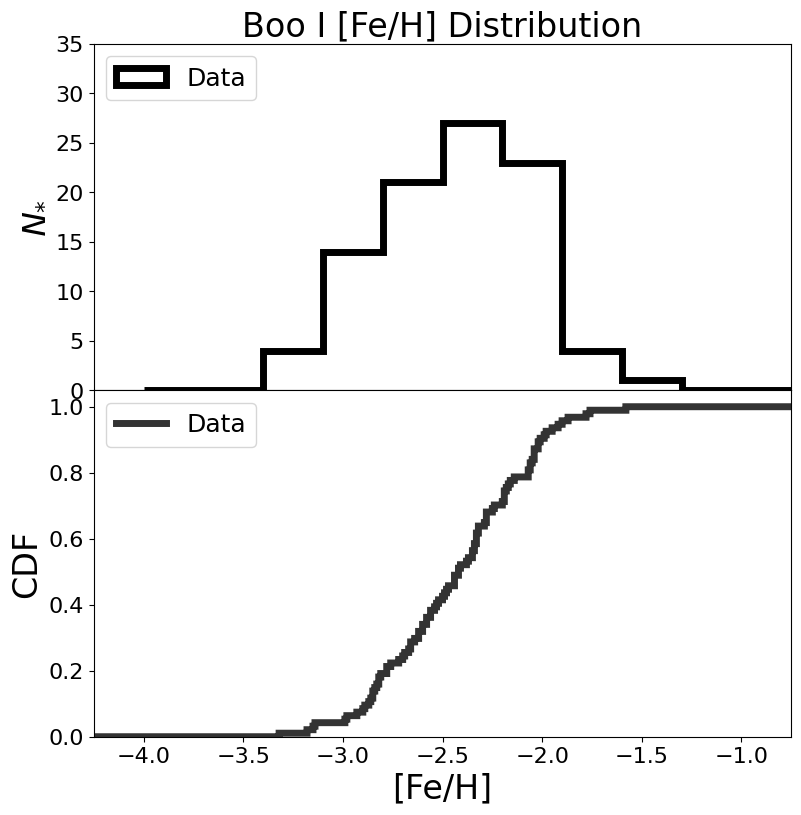

In [3]:
plt.figure(figsize=(9, 9))
gs = GridSpec(2, 1)
gs.update(hspace=0)
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[1, 0], sharex=ax1)

# Make metallicity bins
dFeH = 1e-2  # dex
fine_bins = np.arange(-10, 2.0 + dFeH, dFeH)

# Plot MDF
ax1.hist(
    boo1_df["FeH"],
    color="k",
    histtype="step",
    bins=np.arange(-4, 0, 0.3),
    lw=5,
    label="Data",
    zorder=100,
)

# Plot CMDF
counts, bin_edges = np.histogram(
    boo1_df["FeH"], bins=fine_bins, density=True
)
dx = bin_edges[1] - bin_edges[0]
cdf = np.cumsum(counts * dx)
ax2.stairs(
    cdf,
    fine_bins,
    color="k",
    lw=5,
    ls="-",
    alpha=0.8,
    label="Data",
    zorder=100,
)

ax1.set_title("Boo I [Fe/H] Distribution", fontsize=24)
ax1.set_ylabel(r"$N_{*}$", fontsize=24)
ax2.set_xlabel("[Fe/H]", fontsize=24)
ax2.set_ylabel(r"CDF", fontsize=24)
ax1.set_xlim(-4.25, -0.75)
ax1.set_ylim(0, 35)
ax2.set_ylim(0, 1.05)
ax1.tick_params("x", labelsize=0)
ax1.tick_params("y", labelsize=16)
ax2.tick_params("both", labelsize=16)
ax1.legend(fontsize=18, loc="upper left")
ax2.legend(fontsize=18, loc="upper left")
    
plt.show()

# Accreting Box Model

Let's see if the accreting box model from the textbook (Section 11.2.4) can reproduce the observed MDF of Boo I. As a reminder, the accreting box model makes the following assumptions:
- Instantaneous enrichment, recycling & mixing
- No delayed enrichment (i.e., from Type Ia SNe)
- Outflows parameterized as $\dot{M}_{\mathrm{outflow}} = \eta\,\dot{M}_*$
- Accretion of gas balances outflows in order to maintain a constant star formation rate (i.e., $\dot{M}_{\mathrm{inflow}} = -\dot{M}_{\mathrm{outflow}}$)

The evolution of the metallicity is given by:
\begin{equation}
Z = {p \over 1+\eta-r}\,\left\{1-\exp\left(\left[{1+\eta-r \over 1-r}\right]\,\left[1-{M \over M_g}\right]\right)\right\}
\end{equation}
and the MDF can be represented:
\begin{equation}
{\mathrm{d} N \over \mathrm{d} Z} \propto {1 \over p'-Z}\,,
\end{equation}
where 
\begin{equation}
p' = {p \over 1 + \eta - r}\,.
\end{equation}

In [4]:
def mhdist_accretingbox(mhs, p, eta, r=0.4, e_mh=0.0, Zsolar=0.014):
    """
    MDF of Accreting Box Model as implemented in the textbook (Section 11.2.4).
    Modified from the code used to make Figure 11.8 to include the Recycling Fraction.
    
    Parameters
    ----------
    mhs : array-like
        Array of [M/H] values at which to evaluate the MDF.
    p : float, optional
        Effective yield.
    eta : float, optional
        Infall parameter.
    r : float, optional
        Recycling fraction.
    e_mh : float, optional
        Gaussian smoothing to mimic observational uncertainties.
    Zsolar : float, optional
        Solar metallicity: 0.014 for total. 0.0013 for iron. 0.0056 for magnesium.
    """
    from scipy.ndimage import gaussian_filter1d
    Zs = Zsolar * 10**mhs
    mhdist= Zs / (p / (1 + eta - r) - Zs)
    mhdist[Zs > p / (1 + eta - r)] = 0.
    if e_mh > 0:
        mhdist = gaussian_filter1d(mhdist, e_mh / (mhs[1] - mhs[0]))
    mhdist /= np.sum(mhdist) * (mhs[1] - mhs[0])
    return mhdist


## Comparing to the Default

Let's begin by comparing the MDF predicted by the accreting box model for the Milky Way ($p=0.0035$, $r=0.4$, and $\eta=2.0$). We'll use the median measurement error on [Fe/H] to smooth the model predictions.

Unsuprisingly, this model with these parameters produces a terrible fit to the observed MDF in Boo I, which is substantially more metal-poor than the Solar neighborhood. As a reminder, an accreting box model evolves quickly to an equilibrium metallicity set by the balance of newly produced metals, metals removed by outflows, and pristine gas accretion:

\begin{equation}
\mathrm{[Fe/H]}_\mathrm{eq} = \log10\left(\frac{p}{1 + \eta - r}\right) - \log10\left(Z_\odot\right)\,.
\end{equation}

By design, the choices of $p$, $r$, and $\eta$ chosen here result in an equilibrium abundance that is roughly solar iron abundance ($\mathrm{[Fe/H]}_\mathrm{eq} \sim 0$). Even without doing the formal fitting below, we can estimate what the mass-loading factor must be for this model to fit the Boo I data by solving the above equation for $\eta$:

\begin{equation}
\eta = r - 1 + \frac{p}{Z_\odot}10^{-\mathrm{[Fe/H]}_\mathrm{eq}}\,.
\end{equation}

If we adopt assume that the equilibrium metallicity of Boo I is approximately -2.1 and keep all other values the same, this gives a mass-loading factor of ~340. This is much larger than what is found for the Milky Way!

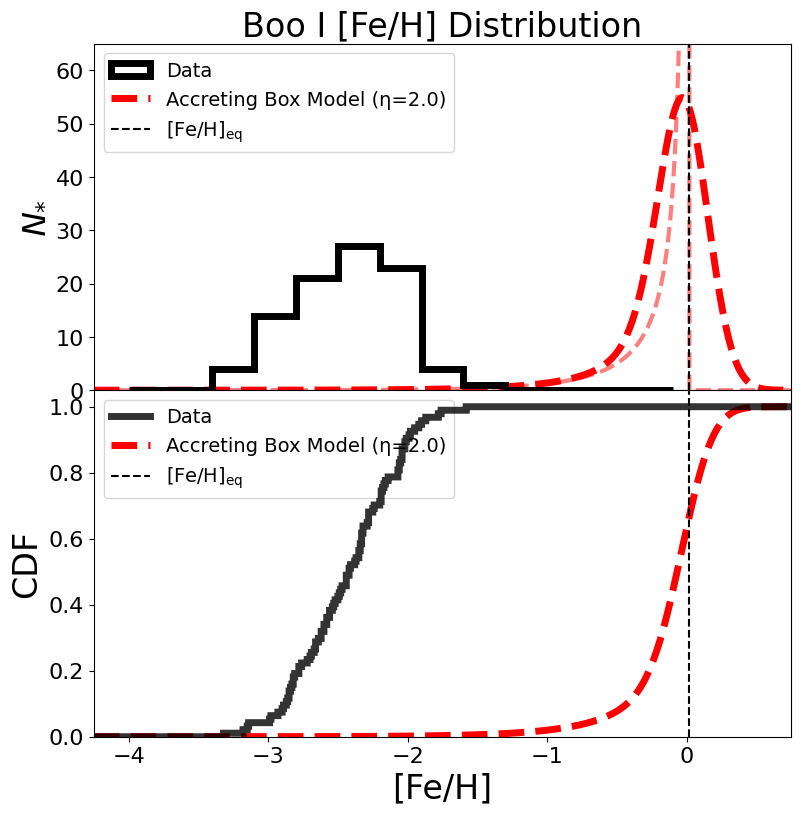

In [5]:
plt.figure(figsize=(9, 9))
gs = GridSpec(2, 1)
gs.update(hspace=0)
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[1, 0], sharex=ax1)

# Make metallicity bins
dFeH = 1e-2  # dex
fine_bins = np.arange(-10, 2.0 + dFeH, dFeH)
# Number of stars (for normalization)
n_star = boo1_df.shape[0]

# Accreting Box Model
mdf_accretingbox = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=boo1_df["FeH_err"].median(),
    r=0.4,
    eta=2.0,
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox *= n_star * 0.3
cmdf_accretingbox = np.cumsum(mdf_accretingbox) * dFeH / 0.3 / n_star

# Accreting Box Model (no error)
mdf_accretingbox_noerr = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=0.0,
    r=0.4,
    eta=2.0,
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox_noerr *= n_star * 0.3
cmdf_accretingbox_noerr = np.cumsum(mdf_accretingbox_noerr) * dFeH / 0.3 / n_star

# Plot MDF
# Data
ax1.hist(
    boo1_df["FeH"],
    color="k",
    histtype="step",
    bins=np.arange(-4, 0, 0.3),
    lw=5,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax1.plot(
    fine_bins,
    mdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=2.0)",
)
# Accreting Box Model (no error)
ax1.plot(
    fine_bins,
    mdf_accretingbox_noerr,
    c='r',
    lw=3,
    ls='--',
    alpha=0.5,
)
# Equilibrium Metallicity
ax1.axvline(
    np.log10(0.0035 / (1 + 2.0 - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)

# Plot CMDF
# Data 
counts, bin_edges = np.histogram(
    boo1_df["FeH"], bins=fine_bins, density=True
)
dx = bin_edges[1] - bin_edges[0]
cdf = np.cumsum(counts * dx)
ax2.stairs(
    cdf,
    fine_bins,
    color="k",
    lw=5,
    ls="-",
    alpha=0.8,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax2.plot(
    fine_bins,
    cmdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=2.0)",
)
# Equilibrium Metallicity
ax2.axvline(
     np.log10(0.0035 / (1 + 2.0 - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)

ax1.set_title("Boo I [Fe/H] Distribution", fontsize=24)
ax1.set_ylabel(r"$N_{*}$", fontsize=24)
ax2.set_xlabel("[Fe/H]", fontsize=24)
ax2.set_ylabel(r"CDF", fontsize=24)
ax1.set_xlim(-4.25, 0.75)
ax1.set_ylim(0, 65)
ax2.set_ylim(0, 1.05)
ax1.tick_params("x", labelsize=0)
ax1.tick_params("y", labelsize=16)
ax2.tick_params("both", labelsize=16)
ax1.legend(fontsize=14, loc="upper left")
ax2.legend(fontsize=14, loc="upper left")
    
plt.show()

## Fitting to the Data

Let's fit the model to the data to see if the accreting box model can reproduce the Boo I MDF with a larger mass-loading factor like that estimated above. We'll hold the yields ($p$) and the recycling fraction ($r$) constant as these are set by stellar physics rather than galactic physics and thus should be the same in both Boo I and the Milky Way (at least to first order). As a result, the only free parameter in this model is the mass-loading factor ($\eta$).

We'll fit the model to the data in a Bayesian framework and write the likelihood of the data as:
\begin{equation}
\ln \mathcal{L} = \sum_{i}\ln\int_{-\infty}^{\infty}\frac{dN}{d\text{[Fe/H]}}\frac{1}{\sqrt{2\pi}\sigma_{\text{[Fe/H]},i}}\exp\left(-\frac{(\text{[Fe/H]} - \text{[Fe/H]}_i)^2}{2\sigma_{\text{[Fe/H]},i}^2}\right)d\text{[Fe/H]}\,,
\end{equation}
and we'll assume a uniform prior on the mass-loading factor of $\eta \sim \mathcal{U}(0, 1000)$.

For legacy compatibility reasons with `ChemWAF`, we'll pass the observed [Fe/H] uncertainties as Gaussian "priors" on the "latent [Fe/H]" measurements. This is a holdover from a previous version of the code that used a hierarchical Bayesian framework where the underlying "true" distribution of the measurements was inferred simultaneously. (Have I used enough "scare quotes" yet?) Suffice it to say that it currently functions as a convenient way to integrate over the Gaussian uncertainties on the measurements.

Note that we are also removing the Gaussian smoothing within the `mhdist_accretingbox` function, as the measurement uncertainties are accounted for in the likelihood function.

In [6]:
def log_likelihood(eta, FeH_Priors):
    dFeH = 1e-2  # dex
    grid = np.arange(-10, 2.0 + dFeH, dFeH)
    feh_pdf = mhdist_accretingbox(
        mhs=grid, 
        p=0.0035, 
        e_mh=0.0,
        eta=eta,
        Zsolar=0.0013,  # Iron solar metallicity
    )
    log_like = np.sum(
        np.log(
            np.trapezoid(feh_pdf * np.exp(FeH_Priors(grid, shared_x=True)), grid, axis=1)
        )
    )
    if np.isnan(log_like):
        raise RuntimeError("NaN found in log_like")
    return log_like


def log_likelihood_wrapper(p, priors):
    """
    Wrapper to parse p  and pass to log_likelihood.
    """
    if p.ndim > 1:
        raise AttributeError("log_prior is not vectorized")
    if np.any(~np.isfinite(p)):
        return -np.inf
    eta = p
    logL = log_likelihood(eta, priors["latent_FeH"])
    return logL


"""
Define Priors
"""
gal_priors = dict(
    eta=UniformLogPrior("eta", 0, 1e3, -np.inf),
)
gal_par_names = list(gal_priors.keys())
FeH_Priors = GaussianLogPrior(
    "latent_FeH", boo1_df["FeH"], boo1_df["FeH_err"]
)
accretingbox_priors = {**gal_priors, **dict(latent_FeH=FeH_Priors)}


tag = "BooI_accretingbox"
priors = accretingbox_priors

"""
Run PMC Sampling
"""
with mp.Pool(mp.cpu_count()) as pool:
    # Sampler initialisation
    sampler = pc.Sampler(
        prior=pc.Prior(
            [priors[key].dist for key in priors.keys() if key != "latent_FeH"]
        ),
        likelihood=log_likelihood_wrapper,
        likelihood_kwargs=dict(
            priors=priors,
        ),
        pool=pool,
    )
    # Run sampler
    sampler.run(
        n_total=5000,
        progress=True,
    )
# Save Results
results = sampler.results
np.savez(
    f"./{tag}_results.npz", **results
)
samples_arr, logl, logp = sampler.posterior(resample=True)
samples = pd.DataFrame(samples_arr, columns=gal_par_names)
samples.to_hdf(
    "./BooI_ChemEv_samples.h5",
    key=f"{tag}",
)

Iter: 28it [00:09,  3.03it/s, beta=1, calls=11264, ESS=4918, logZ=-83.9, logP=-86.3, acc=0.161, steps=1, eff=0.0758] 


Looking at the posterior distribution on $\eta$ below, we see that the Boo I MDF is better fit using the accreting box model with a substantially larger mass-loading factor, $\eta \sim 330$. This is actually quite close to the value estimated above from the assumed equiloibrium metallicity! Qualitatively, this makes sense, as Boo I is much lower mass than the Milky Way, so we would expect supernova feedback to be much more effective at driving outflows that remove gas from the galaxy. We will explore this idea more at the end of this notebook.


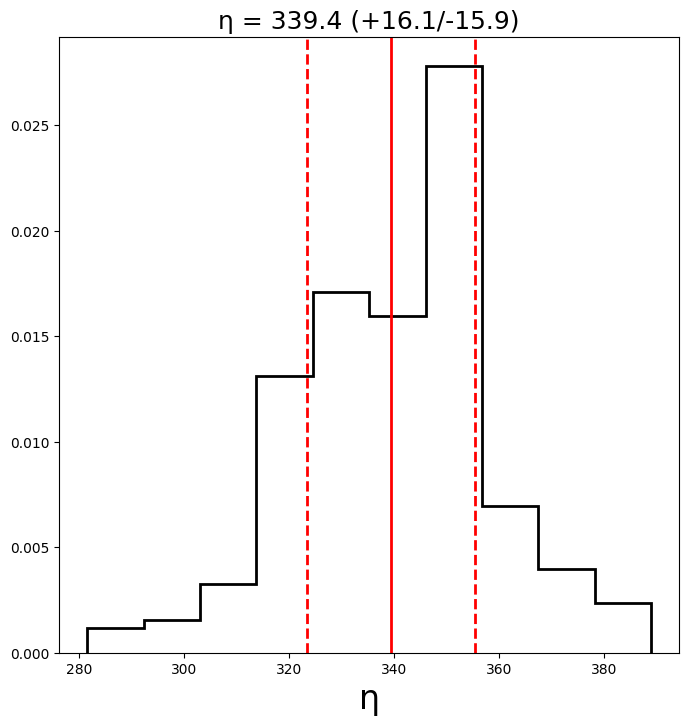

In [7]:
eta16, eta50, eta84 = np.quantile(samples['eta'], q=[0.16, 0.50, 0.84])

plt.figure(figsize=(8, 8))
plt.hist(
    samples['eta'],
    histtype='step',
    color='k',
    lw=2,
    density=True
)
plt.axvline(eta16, color='r', lw=2, ls='--')
plt.axvline(eta50, color='r', lw=2, ls='-')
plt.axvline(eta84, color='r', lw=2, ls='--')
plt.title(f"η = {eta50:.1f} (+{eta84-eta50:.1f}/-{eta50-eta16:.1f})", fontsize=18)
plt.xlabel("η", fontsize=24)
plt.show()


Of course, it's important to check how well the accreting box model with this mass-loading factor actually compares to the data. We can see that the higher mass-loading factor has resulted in a much lower mean metallicity of the predicted MDF, which is roughly in agreement with the mean metallicity of the observed Boo I MDF. This is expected as increased outflows results in more enriched gas being ejected from the galaxy and replaced by pristine accreted gas. However, the model still doesn't fully reproduce the shape of the observed MDF; it is both narrower and lacks the low-metallicity stars that we see in Boo I. We also know that this model can't be completely accurate as it doesn't consider the delayed enrichment of Type Ia supernovae.

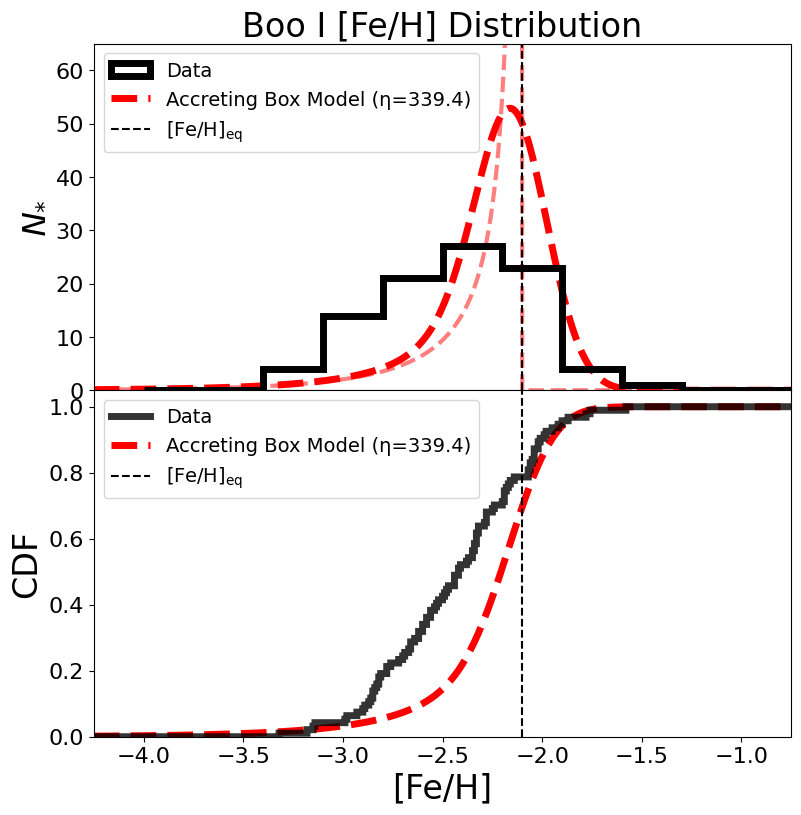

In [8]:
plt.figure(figsize=(9, 9))
gs = GridSpec(2, 1)
gs.update(hspace=0)
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[1, 0], sharex=ax1)

dFeH = 1e-2  # dex
fine_bins = np.arange(-10, 2.0 + dFeH, dFeH)
n_star = boo1_df.shape[0]

# Accreting Box Model
mdf_accretingbox = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=boo1_df["FeH_err"].median(),
    eta=samples["eta"].median(),
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox *= n_star * 0.3
cmdf_accretingbox = np.cumsum(mdf_accretingbox) * dFeH / 0.3 / n_star

# Accreting Box Model (no error)
mdf_accretingbox_noerr = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=0.0,
    eta=samples["eta"].median(),
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox_noerr *= n_star * 0.3
cmdf_accretingbox_noerr = np.cumsum(mdf_accretingbox_noerr) * dFeH / 0.3 / n_star

# Plot MDF
# Data
ax1.hist(
    boo1_df["FeH"],
    color="k",
    histtype="step",
    bins=np.arange(-4, 0, 0.3),
    lw=5,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax1.plot(
    fine_bins,
    mdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label=f"Accreting Box Model (η={samples['eta'].median():.1f})",
)
# Accreting Box Model (no error)
ax1.plot(
    fine_bins,
    mdf_accretingbox_noerr,
    c='r',
    lw=3,
    ls='--',
    alpha=0.5,
)
# Equilibrium Metallicity
ax1.axvline(
    np.log10(0.0035 / (1 + samples['eta'].median() - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)

# Plot CMDF
# Data 
counts, bin_edges = np.histogram(
    boo1_df["FeH"], bins=fine_bins, density=True
)
dx = bin_edges[1] - bin_edges[0]
cdf = np.cumsum(counts * dx)
ax2.stairs(
    cdf,
    fine_bins,
    color="k",
    lw=5,
    ls="-",
    alpha=0.8,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax2.plot(
    fine_bins,
    cmdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label=f"Accreting Box Model (η={samples['eta'].median():.1f})",
)
# Equilibrium Metallicity
ax2.axvline(
    np.log10(0.0035 / (1 + samples['eta'].median() - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)

ax1.set_title("Boo I [Fe/H] Distribution", fontsize=24)
ax1.set_ylabel(r"$N_{*}$", fontsize=24)
ax2.set_xlabel("[Fe/H]", fontsize=24)
ax2.set_ylabel(r"CDF", fontsize=24)
ax1.set_xlim(-4.25, -0.75)
ax1.set_ylim(0, 65)
ax2.set_ylim(0, 1.05)
ax1.tick_params("x", labelsize=0)
ax1.tick_params("y", labelsize=16)
ax2.tick_params("both", labelsize=16)
ax1.legend(fontsize=14, loc="upper left")
ax2.legend(fontsize=14, loc="upper left")
    
plt.show()

# Delayed Accreting Box Model

To more realistically incorporate the enrichment from Type Ia supernovae, let's use the delayed accreting box model from the textbook (Section 11.3.2). As a reminder, the evolution of the metallicity in this model is given by:

\begin{equation}
Z(t) = Z_{\mathrm{Fe}}^{\mathrm{Ia}}(t) + Z_{\mathrm{Fe}}^{\mathrm{II}}(t)\,,
\end{equation}
where 
\begin{align}
Z_{\mathrm{Fe}}^{\mathrm{Ia}}(t) = {p_{\mathrm{Fe}}^{\mathrm{Ia}} \over 1+\eta-r}\ & \left[1-\exp\left(-{t-\Delta t^{\mathrm{Ia}}_{\mathrm{min}}\over \tau_{\mathrm{dep}}}\right)\right.\nonumber\\&\ \ \left.+{\tilde{\tau}\over \tau_{\mathrm{dep}}}\, \left\{\exp\left(-{t-\Delta t^{\mathrm{Ia}}_{\mathrm{min}}\over\tau_{\mathrm{Ia}}}\right)+\exp\left(-{t-\Delta t^{\mathrm{Ia}}_{\mathrm{min}}\over\tau_{\mathrm{dep}}}\right)\right\}\right]\,,
\end{align} 

\begin{equation}
Z_{\mathrm{Fe}}^{\mathrm{II}}(t) = {p_{\mathrm{Fe}}^{\mathrm{II}} \over 1+\eta-r}\ \left[1-e^{-t/\tau_{\mathrm{dep}}}\right]\,,
\end{equation}

and 
\begin{align}
\tilde{\tau}^{-1} = \tau_\mathrm{Ia}^{-1} - \tau_\mathrm{dep}^{-1}
\end{align}
for $t > \Delta t_\mathrm{min}^\mathrm{Ia}$ (the minimum delay time of Type Ia supernovae). In the above equations, the depletion time is defined to be
\begin{align}
\tau_\mathrm{dep} = {\tau_* \over 1 + \eta - r} \,,
\end{align}
where $\tau_* = \frac{M_g}{\dot{M}_*}$ is the star formation efficiency timescale. 

We can calculate the MDF of this model by integrating $Z(t)$ weighted by the star formation rate (which is constant in this model).

The below implementation of this model can use the sum of two exponential delay time distributions to mimic a (broken) powerlaw delay time distribution.



In [9]:
def feh_delayedaccretingbox(
    t,
    p_Fe_Ia=0.001,
    p_Fe_II=0.0011,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1.,
    solar_Fe=7.5,
    eta=2.25,
    r=0.4
):
    """
    [Fe/H] evolution of the accreting box model with a DTD for SNe Ia.
    
    Parameters
    ----------
    t : array-like
        Array of time values at which to evaluate [Fe/H].
    p_Fe_Ia : float, optional
        Fe yield from SNe Ia.
    p_Fe_II : float, optional
        Fe yield from CCSNe.
    tau_Ia : float, optional
        e-folding timescale of the DTD for SNe Ia.
    tau_Ia_2 : float or None, optional
        e-folding timescale of the second component of the DTD for SNe Ia. If None, only a single exponential is used.
    mindt : float, optional
        Minimum delay time for SNe Ia.
    tau_star : float, optional
        Star formation timescale.
    solar_Fe : float, optional
        Solar Fe abundance on the usual logarithmic scale where H=12.
    eta : float, optional
        Infall parameter.
    r : float, optional
        Mass return fraction.
    """
    tau_dep= tau_star / (1. + eta - r)
    tau_tilde= 1. / (1. / tau_Ia - 1. / tau_dep)
    dt = t - mindt
    out = p_Fe_Ia / (1. + eta - r) \
        * (1. - np.exp(-dt / tau_dep) \
        + tau_tilde / tau_dep * (np.exp(-dt / tau_Ia) - np.exp(-dt / tau_dep)))
    # Second exponential Ia component
    if not tau_Ia_2 is None:
        out /= 2.
        tau_tilde = 1. / (1. / tau_Ia_2 - 1. / tau_dep)
        out += p_Fe_Ia / 2. / (1. + eta - r) \
        * (1. - np.exp(-dt / tau_dep) \
        + tau_tilde / tau_dep * (np.exp(-dt / tau_Ia_2) - np.exp(-dt / tau_dep)))
    out[t < mindt]= 0.
    # Add CCSN contribution
    out += p_Fe_II / (1. + eta - r) * (1. - np.exp(-t / tau_dep))
    # Convert to [Fe/H]
    logZFe_solar= -2.90 + solar_Fe - 7.50
    return np.log10(out) - logZFe_solar


def mhdist_delayedaccretingbox(
    t,
    p_Fe_Ia=0.001,
    p_Fe_II=0.0011,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1.,
    solar_Fe=7.5,
    eta=2.25,
    r=0.4,
    mhs=np.arange(-10, 2.0 + 1e-2, 1e-2),
    e_mh=0.0,
):
    """
    MDF of Accreting Box Model
    
    Parameters
    ----------
    t : array-like
        Array of time values at which to evaluate [Fe/H].
    p_Fe_Ia : float, optional
        Fe yield from SNe Ia.
    p_Fe_II : float, optional
        Fe yield from CCSNe.
    tau_Ia : float, optional
        e-folding timescale of the DTD for SNe Ia.
    tau_Ia_2 : float or None, optional
        e-folding timescale of the second component of the DTD for SNe Ia. If None, only a single exponential is used.
    mindt : float, optional
        Minimum delay time for SNe Ia.
    tau_star : float, optional
        Star formation timescale.
    solar_Fe : float, optional
        Solar Fe abundance on the usual logarithmic scale where H=12.
    eta : float, optional
        Infall parameter.
    r : float, optional
        Mass return fraction.
    mhs : array-like, optional
        Bins for the histogram.
    e_mh : float, optional
        Gaussian smoothing to mimic observational uncertainties.
    """
    from scipy.ndimage import gaussian_filter1d
    feh_accbox = feh_delayedaccretingbox(
        t,
        p_Fe_Ia,
        p_Fe_II,
        tau_Ia,
        tau_Ia_2,
        mindt,
        tau_star,
        solar_Fe,
        eta,
        r,
    )
    mhdist = np.histogram(feh_accbox, bins=mhs, density=True)[0]
    if e_mh > 0:
        mhdist = gaussian_filter1d(mhdist, e_mh / (mhs[1] - mhs[0]))
    return mhdist


## Comparing to the Default

Let's now compare the delayed accreting box model to observed Boo I MDF. We'll adopt the same yields, recycling fraction, star formation efficiency timescale, and delay time distribution as in the textbook, but we'll use the mass-loading factor inferred previously from the accreting box model. Again, we'll use the median measurement error on [Fe/H] to smooth the model predictions.

As we can see below, the result is not that dissimilar to what we found for the accreting box model, just with slightly lower metallicity due to the lower total yield assumed here ($p_{\mathrm{Fe}}^{\mathrm{II}} = 0.0017$; $p_{\mathrm{Fe}}^{\mathrm{Ia}}=0.0012$; $p_{\mathrm{Fe}}^{\mathrm{tot}}=0.0029$). If we look closely at the model without errors, we can that the model ends up approaching an equilibrium metallicity at late times:
\begin{equation}
\mathrm{[Fe/H]}_\mathrm{eq} = \log10\left(\frac{p_{\mathrm{Fe}}^{\mathrm{II}} + p_{\mathrm{Fe}}^{\mathrm{Ia}}}{1 + \eta - r}\right) - \log10\left(Z_\odot\right)\,.
\end{equation}
For the adopted values, $\mathrm{[Fe/H]}_\mathrm{eq} = -2.2$.

If we look _really_ close, we can see a sharp spike around $\mathrm{[Fe/H]}\sim-2.5$. This strange feature is the result of the very short depletion timescale for this model (recall the definition of the depletion time above and its dependence on the mass-loading factor). At early times, the chemical enrichment of the model is due solely to core-collapse supernovae, which will drive the metallicity of the galaxy to the equilibrium metallicity set by the core-collapse yields on a timescale set by the depletion timescale. If the depletion timescale is sufficiently shorter than the minimum time delay of Type Ia supernovae, then the galaxy will reach and form stars at this equilibrium until the onset of Type Ia supernovae, at which point the galaxy will evolve to the combined core-collapse plus Type Ia equilibrium. For the values adopted here, $\tau_\mathrm{dep}\sim0.003$ Gyr, which is much smaller than the assumed $\Delta t_\mathrm{min}^\mathrm{Ia}=0.050$ Gyr, and $\mathrm{[Fe/H]}_\mathrm{eq}^\mathrm{II}\sim-2.5$ as expected by the location of the spike. Whether the prediction of this spike is realistic or not is another question, but we note that practically this spike would be difficult to detect observationally given typical observational uncertainties.

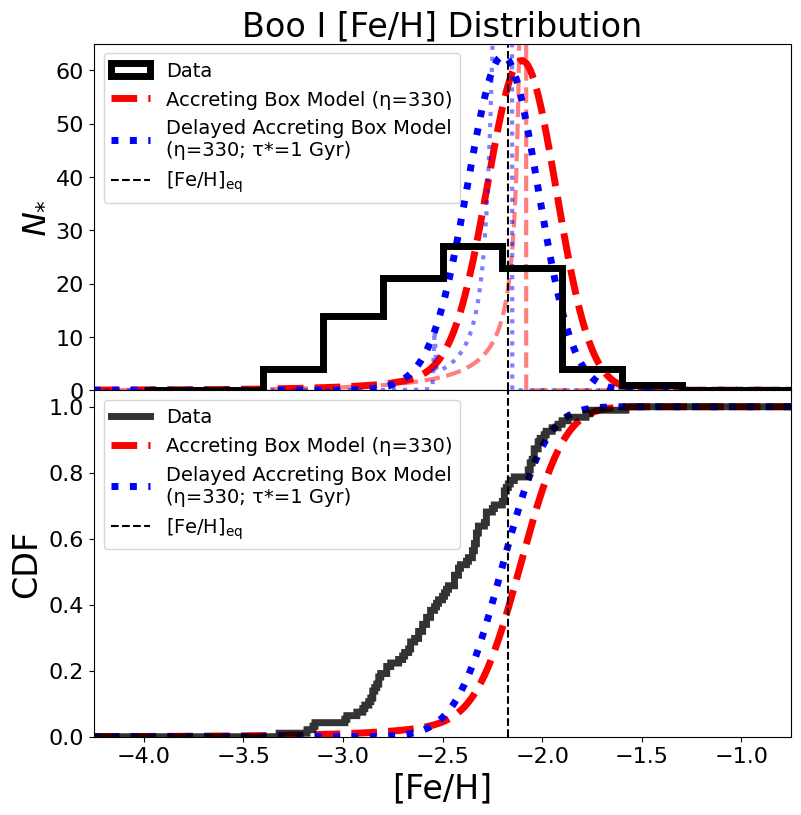

In [10]:
plt.figure(figsize=(9, 9))
gs = GridSpec(2, 1)
gs.update(hspace=0)
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[1, 0], sharex=ax1)

dFeH = 1e-2  # dex
fine_bins = np.arange(-10, 2.0 + dFeH, dFeH)
n_star = boo1_df.shape[0]
dt = 1e-5  # Gyr
t_trunc = 10  # Gyr
t = np.arange(dt, t_trunc + dt, dt)

# Accreting Box Model
mdf_accretingbox = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=boo1_df["FeH_err"].median(),
    eta=330,
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox *= n_star * 0.3
cmdf_accretingbox = np.cumsum(mdf_accretingbox) * dFeH / 0.3 / n_star
# Accreting Box Model (no error)
mdf_accretingbox_noerr = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=0.0,
    eta=330,
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox_noerr *= n_star * 0.3
cmdf_accretingbox_noerr = np.cumsum(mdf_accretingbox_noerr) * dFeH / 0.3 / n_star

# Delayed Accreting Box Model
mdf_delayaccretingbox = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1,
    solar_Fe=7.5,
    eta=330,
    r=0.4,
    mhs=fine_bins,
    e_mh=boo1_df["FeH_err"].median(),
)
mdf_delayaccretingbox *= n_star * 0.3
cmdf_delayaccretingbox = np.cumsum(mdf_delayaccretingbox) * dFeH / 0.3 / n_star
# Delayed Accreting Box Model (no error)
mdf_delayaccretingbox_noerr = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1,
    solar_Fe=7.5,
    eta=330,
    r=0.4,
    mhs=fine_bins,
    e_mh=0.0,
)
mdf_delayaccretingbox_noerr *= n_star * 0.3
cmdf_delayaccretingbox_noerr = np.cumsum(mdf_delayaccretingbox_noerr) * dFeH / 0.3 / n_star

# Plot MDF
# Data
ax1.hist(
    boo1_df["FeH"],
    color="k",
    histtype="step",
    bins=np.arange(-4, 0, 0.3),
    lw=5,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax1.plot(
    fine_bins,
    mdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Accreting Box Model (no error)
ax1.plot(
    fine_bins,
    mdf_accretingbox_noerr,
    c='r',
    lw=3,
    ls='--',
    alpha=0.5,
)
# Delayed Accreting Box Model
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label="Delayed Accreting Box Model\n(η=330; τ*=1 Gyr)",
)
# Delayed Accreting Box Model (no error)
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox_noerr,
    c='b',
    lw=3,
    ls=':',
    alpha=0.5,
)
# Equilibrium Metallicity
ax1.axvline(
    np.log10(0.0029 / (1 + 330 - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)
# Equilibrium Metallicity
# ax1.axvline(
#     np.log10(0.0012 / (1 + 330 - 0.4)) - np.log10(0.0013),
#     c='gray',
#     ls='--',
#     label=r'$\mathrm{[Fe/H]}_\mathrm{eq}^\mathrm{II}$',
# )

# Plot CMDF
# Data 
counts, bin_edges = np.histogram(
    boo1_df["FeH"], bins=fine_bins, density=True
)
dx = bin_edges[1] - bin_edges[0]
cdf = np.cumsum(counts * dx)
ax2.stairs(
    cdf,
    fine_bins,
    color="k",
    lw=5,
    ls="-",
    alpha=0.8,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax2.plot(
    fine_bins,
    cmdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Delayed Accreting Box Model
ax2.plot(
    fine_bins[1:],
    cmdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label="Delayed Accreting Box Model\n(η=330; τ*=1 Gyr)",
)
# Equilibrium Metallicity
ax2.axvline(
    np.log10(0.0029 / (1 + 330 - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)
# Equilibrium Metallicity
# ax2.axvline(
#     np.log10(0.0012 / (1 + 330 - 0.4)) - np.log10(0.0013),
#     c='gray',
#     ls='--',
#     label=r'$\mathrm{[Fe/H]}_\mathrm{eq}^\mathrm{II}$',
# )

ax1.set_title("Boo I [Fe/H] Distribution", fontsize=24)
ax1.set_ylabel(r"$N_{*}$", fontsize=24)
ax2.set_xlabel("[Fe/H]", fontsize=24)
ax2.set_ylabel(r"CDF", fontsize=24)
ax1.set_xlim(-4.25, -0.75)
ax1.set_ylim(0, 65)
ax2.set_ylim(0, 1.05)
ax1.tick_params("x", labelsize=0)
ax1.tick_params("y", labelsize=16)
ax2.tick_params("both", labelsize=16)
ax1.legend(fontsize=14, loc="upper left")
ax2.legend(fontsize=14, loc="upper left")
    
plt.show()

## Fitting to the Data

Let's once again fit the model to the data, this time to see if the delayed accreting box model can reproduce the Boo I MDF with a different set of parameters. We'll fix all of the parameters except for the mass-loading factor ($\eta$) and the star formation efficiency timescale ($\tau_*). We'll use the same likelihood function as before and adopt the following priors:
- $\eta \sim \mathcal{U}(0, 1000)$
- $\log \tau_* \sim \mathcal{U}(-1, 5)$

Note that we've chosen to fit $\log\tau_*$, which isn't strictly necessary.

In [11]:
def log_likelihood(tau_star, eta, FeH_Priors):
    dFeH = 1e-2  # dex
    grid = np.arange(-10, 2.0 + dFeH, dFeH)
    dt = 1e-5  # Gyr
    t_trunc = 10  # Gyr
    t = np.arange(dt, t_trunc + dt, dt)
    feh_pdf = mhdist_delayedaccretingbox(
        t,
        p_Fe_Ia=0.0017,
        p_Fe_II=0.0012,
        tau_Ia=0.4,
        tau_Ia_2=3.3,
        mindt=0.05,
        tau_star=tau_star,
        solar_Fe=7.5,
        eta=eta,
        r=0.4,
        mhs=grid,
        e_mh=0.0,
    )
    log_like = np.sum(
        np.log(
            np.trapezoid(feh_pdf * np.exp(FeH_Priors(grid[1:], shared_x=True)), grid[1:], axis=1)
        )
    )
    if np.isnan(log_like):
        raise RuntimeError("NaN found in log_like")
    return log_like


def log_likelihood_wrapper(p, priors):
    """
    Wrapper to parse p  and pass to log_likelihood
    """
    if p.ndim > 1:
        raise AttributeError("log_prior is not vectorized")
    if np.any(~np.isfinite(p)):
        return -np.inf
    tau_star = 10**p[0]
    eta = p[1]
    logL = log_likelihood(tau_star, eta, priors["latent_FeH"])
    return logL


"""
Define Priors
"""
gal_priors = dict(
    log_tau_star=UniformLogPrior("log_tau_star", -1, 5, -np.inf),
    eta=UniformLogPrior("eta", 0, 1e3, -np.inf),
)
gal_par_names = list(gal_priors.keys())
FeH_Priors = GaussianLogPrior(
    "latent_FeH", boo1_df["FeH"], boo1_df["FeH_err"]
)
delayedaccretingbox_priors = {**gal_priors, **dict(latent_FeH=FeH_Priors)}


tag = "BooI_delayedaccretingbox"
priors = delayedaccretingbox_priors

"""
Run PMC Sampling
"""
with mp.Pool(mp.cpu_count()) as pool:
    # Sampler initialisation
    sampler = pc.Sampler(
        prior=pc.Prior(
            [priors[key].dist for key in priors.keys() if key != "latent_FeH"]
        ),
        likelihood=log_likelihood_wrapper,
        likelihood_kwargs=dict(
            priors=priors,
        ),
        pool=pool,
    )
    # Run sampler
    sampler.run(
        n_total=5000,
        progress=True,
    )
# Save Results
results = sampler.results
np.savez(
    f"./{tag}_results.npz", **results
)
samples_arr, logl, logp = sampler.posterior(resample=True)
samples = pd.DataFrame(samples_arr, columns=gal_par_names)
samples.to_hdf(
    "./BooI_ChemEv_samples.h5",
    key=f"{tag}",
)

Iter: 30it [04:14,  8.47s/it, beta=1, calls=40192, ESS=4889, logZ=-53.6, logP=-56.5, acc=0.867, steps=4, eff=0.588]   


Looking at the posterior distribution of $\tau_*$ and $\eta$ below, we see that the delayed accreting box model fits the Boo I MDF better when the star formation efficiency time scale is substantially larger, $\tau_*\sim 1800$. In other words, Boo I must be much less efficient at converting gas into stars than the Milky Way. Qualitatively, this is in agreement with our current understanding that star formation is less efficient in low-mass galaxies, however the magnitude of the $\tau_*$ is likely unrealistically large. The mass-loading factor is not very well constrained in this scenario; it could be as low as 0 or as high as 100 (though at low probability). We can also see that it is partially degenerate with the star formation efficiency time scale. We will discuss this further, below, and for arguments sake adopt the median mass-loading factor from the posterior ($\eta\sim40$).


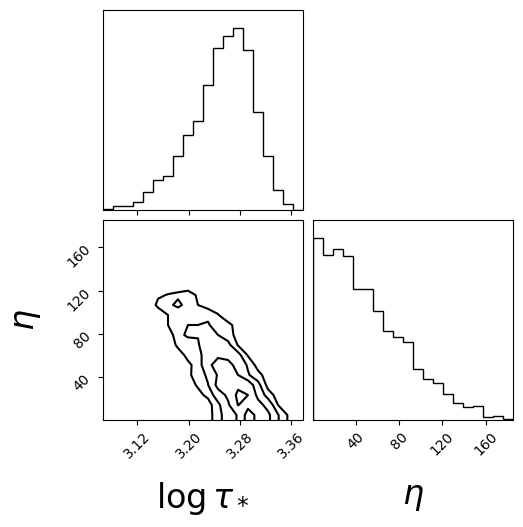

In [12]:
# Posterior Corner Plot
fig = corner(
    samples,
    labels=[
        r"$\log\tau_*$",
        r"$\eta$",
    ],
    plot_datapoints=False,
    plot_density=False,
    titles=True,
    color="black",
    hist_kwargs={"histtype": "step", "density": True},
    label_kwargs={"fontsize": 24},
)
plt.show()

Now let's check how well the delayed accreting box model with this mass-loading factor actually compares to the data using the median posterior values. While it's still not a perfect fit, we can see that the predicted MDF not only has a peak metallicity similar to the observed MDF, it is also wider and has a more pronounced metal-poor tail. This is due the much lower star formation efficiency, which requires a much larger reservoir of (initially pristine) gas relative to the amount of star formation. As a result, the galaxy is enriched more slowly, giving more time for stars to form at low-metallicity. This also explains why the mass-loading factor is less-well constrained. Because there is more gas and the gas is less enriched, the effect of outflows is smaller as is their impact on the shape of the MDF.

When looking at the figure below, we can also see that the model actually never reaches the equilibrium metallicity, which is now significantly larger due to the smaller mass-loading factor. This is because the depletion timescale is much longer given the larger star formation efficiency timescale ($\tau_\mathrm{dep}\sim45$ Gyr). It's worth noting that a large depletion time is not the only way to ensure that this model does not reach its equilibrium abundance. In this example, the model is run for a total of 10 Gyr. However, we know from isochrone fitting of Boo I's color-magnitude diagram, that Boo I stopped forming stars almost 13 Gyr ago. That is, it only formed stars for $\sim$1 Gyr. Though we will not do so here, one could adjust the `t_trunc` parameter in the above cells so that the model runs for a short period of time. This would allow for similar model predictions with smaller star formation efficiency timescales. We will explore this idea more in the next section when we look at non-constant star formation rates.

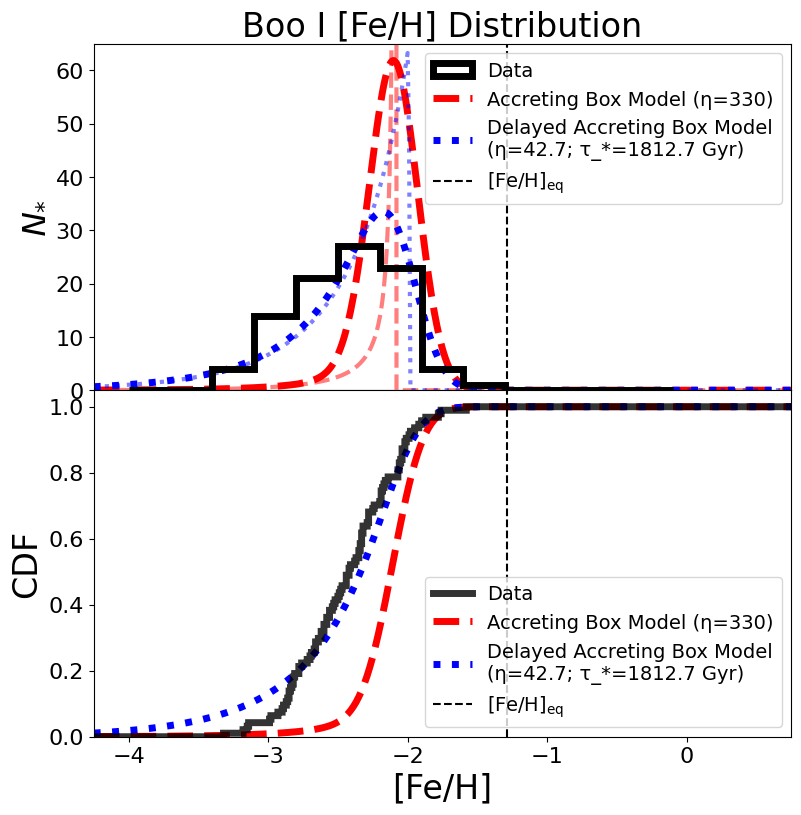

In [13]:
plt.figure(figsize=(9, 9))
gs = GridSpec(2, 1)
gs.update(hspace=0)
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[1, 0], sharex=ax1)

dFeH = 1e-2  # dex
fine_bins = np.arange(-10, 2.0 + dFeH, dFeH)
n_star = boo1_df.shape[0]
dt = 1e-5  # Gyr
t_trunc = 10
t = np.arange(dt, t_trunc + dt, dt)

# Accreting Box Model
mdf_accretingbox = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=boo1_df["FeH_err"].median(),
    eta=330,
    Zsolar=0.0013
)
mdf_accretingbox *= n_star * 0.3
cmdf_accretingbox = np.cumsum(mdf_accretingbox) * dFeH / 0.3 / n_star
# Accreting Box Model (no error)
mdf_accretingbox_noerr = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=0.0,
    eta=330,
    Zsolar=0.0013
)
mdf_accretingbox_noerr *= n_star * 0.3
cmdf_accretingbox_noerr = np.cumsum(mdf_accretingbox_noerr) * dFeH / 0.3 / n_star

# Delayed Accreting Box Model
mdf_delayaccretingbox = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=10**samples["log_tau_star"].median(),
    solar_Fe=7.5,
    eta=samples["eta"].median(),
    r=0.4,
    mhs=fine_bins,
    e_mh=boo1_df["FeH_err"].median(),
)
mdf_delayaccretingbox *= n_star * 0.3
cmdf_delayaccretingbox = np.cumsum(mdf_delayaccretingbox) * dFeH / 0.3 / n_star
# Delayed Accreting Box Model (no error)
mdf_delayaccretingbox_noerr = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=10**samples["log_tau_star"].median(),
    solar_Fe=7.5,
    eta=samples["eta"].median(),
    r=0.4,
    mhs=fine_bins,
    e_mh=0.0,
)
mdf_delayaccretingbox_noerr *= n_star * 0.3
cmdf_delayaccretingbox_noerr = np.cumsum(mdf_delayaccretingbox_noerr) * dFeH / 0.3 / n_star

# Plot MDF
# Data
ax1.hist(
    boo1_df["FeH"],
    color="k",
    histtype="step",
    bins=np.arange(-4, 0, 0.3),
    lw=5,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax1.plot(
    fine_bins,
    mdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Accreting Box Model (no error)
ax1.plot(
    fine_bins,
    mdf_accretingbox_noerr,
    c='r',
    lw=3,
    ls='--',
    alpha=0.5,
)
# Delayed Accreting Box Model
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label=f"Delayed Accreting Box Model\n(η={samples['eta'].median():.1f}; τ_*={10**samples['log_tau_star'].median():.1f} Gyr)",
)
# Delayed Accreting Box Model (no error)
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox_noerr,
    c='b',
    lw=3,
    ls=':',
    alpha=0.5,
)

# Equilibrium Metallicity
ax1.axvline(
    np.log10(0.0029 / (1 + samples['eta'].median() - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)

# Plot CMDF
# Data 
counts, bin_edges = np.histogram(
    boo1_df["FeH"], bins=fine_bins, density=True
)
dx = bin_edges[1] - bin_edges[0]
cdf = np.cumsum(counts * dx)
ax2.stairs(
    cdf,
    fine_bins,
    color="k",
    lw=5,
    ls="-",
    alpha=0.8,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax2.plot(
    fine_bins,
    cmdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Delayed Accreting Box Model
ax2.plot(
    fine_bins[1:],
    cmdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label=f"Delayed Accreting Box Model\n(η={samples['eta'].median():.1f}; τ_*={10**samples['log_tau_star'].median():.1f} Gyr)",
)
# Equilibrium Metallicity
ax2.axvline(
    np.log10(0.0029 / (1 + samples['eta'].median() - 0.4)) - np.log10(0.0013),
    c='k',
    ls='--',
    label=r'$\mathrm{[Fe/H]}_\mathrm{eq}$',
)

ax1.set_title("Boo I [Fe/H] Distribution", fontsize=24)
ax1.set_ylabel(r"$N_{*}$", fontsize=24)
ax2.set_xlabel("[Fe/H]", fontsize=24)
ax2.set_ylabel(r"CDF", fontsize=24)
ax1.set_xlim(-4.25, 0.75)
ax1.set_ylim(0, 65)
ax2.set_ylim(0, 1.05)
ax1.tick_params("x", labelsize=0)
ax1.tick_params("y", labelsize=16)
ax2.tick_params("both", labelsize=16)
ax1.legend(fontsize=14, loc="upper right")
ax2.legend(fontsize=14, loc="lower right")
    
plt.show()

# Weingberg, Andrews, and Freudenburg (2017) Model

As a final step in our chemical evolution analysis, we'll consider a slightly more flexible (but just as analytic!) model developed in [Weinberg, Andrews, and Freudenburg (2017)](https://ui.adsabs.harvard.edu/abs/2017ApJ...837..183W/abstract) and applied to dwarf galaxies in [Sandford et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024MNRAS.530.2315S/abstract) and [Sandford et al. (2026)](https://ui.adsabs.harvard.edu/abs/2026ApJ...998...47S/abstract). This model is actually nearly identical to the delayed accreting model used above, except that it relaxes the assumption of a constant star formation rate. For the Milky Way disk, a constant star formation rate is a reasonable simplification, especially given how difficult is to measure the Milky Way's past star formation. However, the dwarf galaxies that we are considering for this project are ubiquitously old as measured from deep Hubble color-magnitude diagrams. That is, their star formation rate declined rapidly and quenched within the first ~1-5 billion years (presumably due to ram pressure stripping when they fell into the Milky Way halo, though some of the smallest and oldest may have been quenched by the re-ionization of the Universe).

In short, these models allow for a few functional forms of the star formation history that still have analytic solutions:
- $\dot{M}_*\propto C$ (Constant SFH)
- $\dot{M}_*\propto \exp(-t/\tau_\text{SFH})$ (Exponential SFH)
- $\dot{M}_*\propto t\exp(-t/\tau_\text{SFH})$ (Linear-Exponential SFH)

The mass of accreted gas is then set implicitly by the SFH, star formation efficiency timecale, and mass recycling fraction, and mass-loading factor, such that the depletion of gas by star formation and outflows is sufficiently balanced to maintain the specified $\dot{M}_*$. This model also allows the duration of the simulation to be set by a free parameter, the truncation time, $t_\mathrm{trunc}$. This can be used to abruptly turn off star formation at a specified time to crudely mimic quenching. For a full description of the model, see the above papers. For an implementation of the models, see the function `waf.models.waf2017`.

In the application of the model below, we adopt the yields, delay time distributions, and solar abundances used in Sandford et al. 2024 and 2026. In principal, we could convert these values to be consistent with the above models, but we won't. Instead, we note that self-consistent versions of the accreting and delayed accreting box models can be produced by this model with the right combination of parameters if a true 1-to-1 comparison is desired:
- For the accreting box model, set `SFH_fn = "constant"`, remove any reference to `tauSFH`, and set `yFeIa = 0.0`, which turns off enrichement from Type Ia supernova.
- For the delayed accreting box model, set `SFH_fn = "constant"` and remove any reference to `tauSFH`. 

For the following analysis, we will adopt a exponential SFH (though a linear-exponential SFH should produce similar results).

## Comparing to the Default

Let's now compare the WAF2017 model to observed Boo I MDF. As mentioned above, we'll switch to use the default yields, recycling fraction, delay time distribution, and Solar scale as in Sandford et al. (2026). This choice shouldn't make a huge qualitative difference to our results, but will shift the numerical results slightly. Specifically, the adopted yields are smaller, so we will see the predicted metallicities be smaller as well. For this comparison, we'll adopt the star formation efficiency timescale and mass-loading factor from the delayed accretion model. Again, we'll use the median measurement error on [Fe/H] to smooth the model predictions. For the linear-exponential star formation, we'll assume a 1 Gyr timescale as a baseline and let the model run for 10 Gyr as before. 

As we can see below, this model predicts both a lower mean metallicity as well as a much wider and more symmetric metallicity distribution. Unlike for the previous models where the high-metallicity tail is the result of scatter from measurement uncertainty, the high-metallicity tail here is the result of delayed Type Ia supernova enrichment into a shrinking gas reservoir. We omit the equilibrium metallicities in the plots below because they are a bit more complicated (see Equations 28-30 in the WAF2017 paper) now that there are quite a few timescales involved. Moreover, we will see that like for the delayed accreting box model, the equilibrium metallicity is never reached.


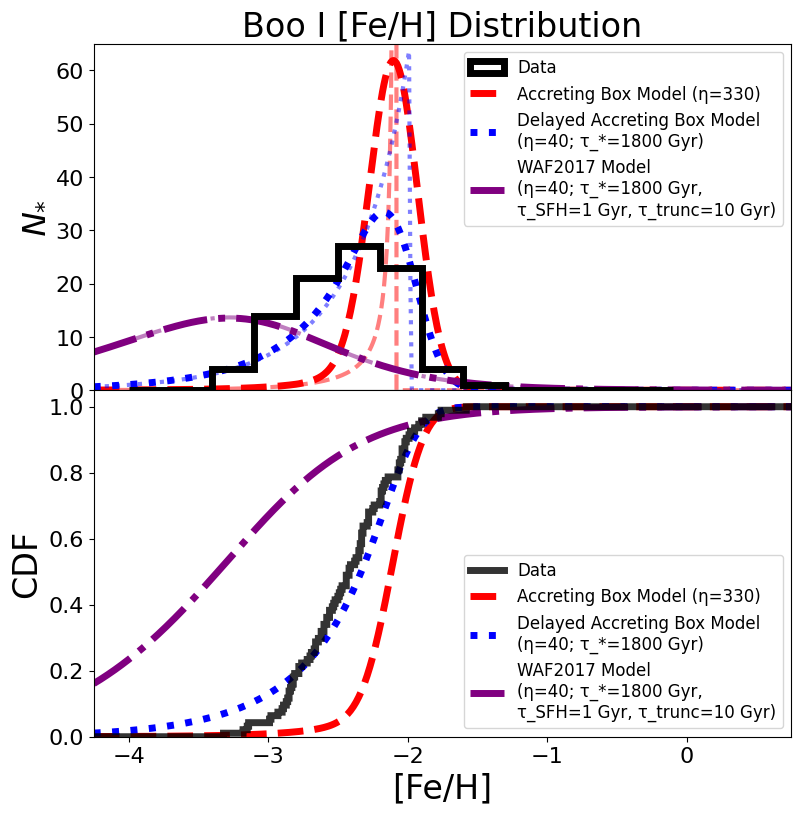

In [14]:
plt.figure(figsize=(9, 9))
gs = GridSpec(2, 1)
gs.update(hspace=0)
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[1, 0], sharex=ax1)

dFeH = 1e-2  # dex
fine_bins = np.arange(-10, 2.0 + dFeH, dFeH)
n_star = boo1_df.shape[0]
dt = 1e-5  # Gyr
t_trunc = 10  # Gyr 
t = np.arange(dt, t_trunc + dt, dt)

# WAF2017 Model
SFH_fn = "exponential"  # exponential SFH; SFR ~ exp(-t/tau);
IaDTD_fn = "powerlaw"  # SN Ia delay time distribution; -1.1 Powerlaw DTD (sum of two exponentials); Maoz+ (2012)
tDminIa = 0.05  # Minimum SN Ia Time Delay; Gyr; Maoz+ (2012)
r = 0.37  # Recycling fraction; Kroupa IMF after 1 Gyr
SolarFe = 0.0013  # Iron Solar Scale; Asplund (2009)
SolarAlphaMg = 0.0007  # Magnesium Solar Scale; Asplund (2009)
yFeCC = 0.0006  # Core-collapse SN Iron Yields
yFeIa = 0.0012  # SN Ia Iron Yields Yields
yAlphaMgCC = 0.001  # Core-collapse SN Mg Yields
SolarAlpha = SolarAlphaMg
yAlphaCC = yAlphaMgCC
fRet = fRetCC = fRetIa = 1.0  # Metal Retention Factor; decrease to implement metal-enriched outflows
default_par = DefaultParSet()
default_par.update(
    {
        "SFH_fn": SFH_fn,
        "IaDTD_fn": IaDTD_fn,
        "tDminIa": tDminIa,
        "r": r,
        "dt": dt,
        "SolarAlpha": SolarAlpha,
        "SolarFe": SolarFe,
        "yAlphaCC": yAlphaCC,
        "yFeCC": yFeCC,
        "yFeIa": yFeIa,
        "fRet": fRet,
        "eta": 40,
        "tauSFE": 1800,
        "tauSFH": 1.0,
        "t_trunc": 10,
    }
)
sfr, oh, feh, ofe = waf2017(**default_par.model_kwargs)
feh_pdf, grid = get_PDF(
    feh,
    sfr,
    grid=fine_bins,
    lower_bound=-np.inf,
    floor=1e-20,
)
feh_pdf_noerr = feh_pdf.copy()
feh_pdf_noerr *= n_star * 0.3
feh_cdf_noerr = np.cumsum(feh_pdf_noerr) * dFeH / 0.3 / n_star

feh_pdf = gaussian_filter1d(feh_pdf, 0.1 / (grid[1] - grid[0]))
feh_pdf *= n_star * 0.3
feh_cdf = np.cumsum(feh_pdf) * dFeH / 0.3 / n_star



# Accreting Box Model
mdf_accretingbox = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=boo1_df["FeH_err"].median(),
    eta=330,
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox *= n_star * 0.3
cmdf_accretingbox = np.cumsum(mdf_accretingbox) * dFeH / 0.3 / n_star
# Accreting Box Model (no error)
mdf_accretingbox_noerr = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=0.0,
    eta=330,
    Zsolar=0.0013,  # Iron solar metallicity
)
mdf_accretingbox_noerr *= n_star * 0.3
cmdf_accretingbox_noerr = np.cumsum(mdf_accretingbox_noerr) * dFeH / 0.3 / n_star

# Delayed Accreting Box Model
mdf_delayaccretingbox = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1800,
    solar_Fe=7.5,
    eta=40,
    r=0.4,
    mhs=fine_bins,
    e_mh=boo1_df["FeH_err"].median(),
)
mdf_delayaccretingbox *= n_star * 0.3
cmdf_delayaccretingbox = np.cumsum(mdf_delayaccretingbox) * dFeH / 0.3 / n_star
# Delayed Accreting Box Model (no error)
mdf_delayaccretingbox_noerr = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1800,
    solar_Fe=7.5,
    eta=40,
    r=0.4,
    mhs=fine_bins,
    e_mh=0.0,
)
mdf_delayaccretingbox_noerr *= n_star * 0.3
cmdf_delayaccretingbox_noerr = np.cumsum(mdf_delayaccretingbox_noerr) * dFeH / 0.3 / n_star

# Plot MDF
# Data
ax1.hist(
    boo1_df["FeH"],
    color="k",
    histtype="step",
    bins=np.arange(-4, 0, 0.3),
    lw=5,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax1.plot(
    fine_bins,
    mdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Accreting Box Model (no error)
ax1.plot(
    fine_bins,
    mdf_accretingbox_noerr,
    c='r',
    lw=3,
    ls='--',
    alpha=0.5,
)
# Delayed Accreting Box Model
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label="Delayed Accreting Box Model\n(η=40; τ_*=1800 Gyr)",
)
# Delayed Accreting Box Model (no error)
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox_noerr,
    c='b',
    lw=3,
    ls=':',
    alpha=0.5,
)
# WAF2017 Model
ax1.plot(
    grid,
    feh_pdf,
    c='purple',
    lw=5,
    ls='-.',
    label="WAF2017 Model\n(η=40; τ_*=1800 Gyr,\nτ_SFH=1 Gyr, τ_trunc=10 Gyr)",
)
# WAF2017 Model (no error)
ax1.plot(
    grid,
    feh_pdf_noerr,
    c='purple',
    lw=3,
    ls='-.',
    alpha=0.5,
)


# Plot CMDF
# Data 
counts, bin_edges = np.histogram(
    boo1_df["FeH"], bins=fine_bins, density=True
)
dx = bin_edges[1] - bin_edges[0]
cdf = np.cumsum(counts * dx)
ax2.stairs(
    cdf,
    fine_bins,
    color="k",
    lw=5,
    ls="-",
    alpha=0.8,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax2.plot(
    fine_bins,
    cmdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Delayed Accreting Box Model
ax2.plot(
    fine_bins[1:],
    cmdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label="Delayed Accreting Box Model\n(η=40; τ_*=1800 Gyr)",
)
# WAF2017 Model
ax2.plot(
    grid,
    feh_cdf,
    c='purple',
    lw=5,
    ls='-.',
    label="WAF2017 Model\n(η=40; τ_*=1800 Gyr,\nτ_SFH=1 Gyr, τ_trunc=10 Gyr)",
)

ax1.set_title("Boo I [Fe/H] Distribution", fontsize=24)
ax1.set_ylabel(r"$N_{*}$", fontsize=24)
ax2.set_xlabel("[Fe/H]", fontsize=24)
ax2.set_ylabel(r"CDF", fontsize=24)
ax1.set_xlim(-4.25, 0.75)
ax1.set_ylim(0, 65)
ax2.set_ylim(0, 1.05)
ax1.tick_params("x", labelsize=0)
ax1.tick_params("y", labelsize=16)
ax2.tick_params("both", labelsize=16)
ax1.legend(fontsize=12, loc="upper right")
ax2.legend(fontsize=12, loc="lower right")
    
plt.show()

## Fitting to the Data

Obviously the parameters adopted above do not work especially well for Boo I, so let's try to find a set of parameters that do. Here, the free parameters will again be the mass-loading factor ($\eta$) and the star formation efficiency timescale ($\tau_*$), as well as the star formation history timescale ($\tau_\mathrm{SFH}$) and the truncation time ($t\mathrm{trunc}$). We'll use the same likelihood function as before and adopt the following priors:
- $\eta \sim \mathcal{U}(0, 1000)$
- $\log \tau_* \sim \mathcal{U}(-1, 5)$
- $\tau_\mathrm{SFH} \sim \mathcal{U}(0.05, 1)$
- $t_\mathrm{trunc} \sim \mathcal{U}(0, 2)$

Note that we have forced the star formation history timescale to be quite short and the truncation of the star formation to be quite early. This is motivated by existing measurements of Boo I's star formation history from deep photometric studies. In the case of Boo I, the duration of the star formation is not resolved by the photometry, so we implement an effective upper limit of 1 Gyr. If the star formation history was resolved, as it is for some other dwarfs, we could incorporate that information via more informative prior on $\tau_\mathrm{SFH}$ and $t_\mathrm{trunc}$. This reveals another advantage of writing the model in terms of the star formation history rather than the gas accretion history: the star formation history can be independently constrained by observations, while the gas accretion history must typically be assumed from simulations.

In [ ]:
def log_likelihood(p_gal, par, FeH_Priors, floor=1e-20):
    par.update(p_gal)
    sfr, oh, feh, ofe = waf2017(**par.model_kwargs)
    if (
        ~np.all(np.isfinite(oh))
        or ~np.all(np.isfinite(feh))
        or ~np.all(np.isfinite(ofe))
    ):
        return -np.inf
    feh_pdf, grid = get_PDF(
        feh,
        sfr,
        grid=None,
        lower_bound=-4,
        upper_bound=None,
        boundary_dist="HalfNormal",
        boundary_width=0.35,
        floor=floor,
    )
    log_like = np.sum(
        np.log(
            np.trapezoid(feh_pdf * np.exp(FeH_Priors(grid, shared_x=True)), grid, axis=1)
        )
    )
    if np.isnan(log_like):
        raise RuntimeError("NaN found in log_like")
    return log_like


def log_likelihood_wrapper(p, priors, par, gal_par_names, floor=1e-20):
    """
    Wrapper to parse p into p_gal and p_star and pass to log_likelihood
    """
    if p.ndim > 1:
        raise AttributeError("log_prior is not vectorized")
    if np.any(~np.isfinite(p)):
        return -np.inf
    p_gal = {
        par_name: p[: len(gal_par_names)][i] for i, par_name in enumerate(gal_par_names)
    }
    logL = log_likelihood(p_gal, par, priors["latent_FeH"], floor)
    return logL


"""
Default Parameters
"""
SFH_fn = "exponential"  # exponential SFH; SFR ~ exp(-t/tau);
IaDTD_fn = "powerlaw"  # SN Ia delay time distribution; -1.1 Powerlaw DTD (sum of two exponentials); Maoz+ (2012)
tDminIa = 0.05  # Minimum SN Ia Time Delay; Gyr; Maoz+ (2012)
r = 0.4  # Recycling fraction; Kroupa IMF after 1 Gyr
SolarFe = 0.0013  # Iron Solar Scale; Asplund (2009)
SolarAlphaMg = 0.0007  # Magnesium Solar Scale; Asplund (2009)
yFeCC = 0.0006  # Core-collapse SN Iron Yields
yFeIa = 0.0012  # SN Ia Iron Yields Yields
yAlphaMgCC = 0.001  # Core-collapse SN Mg Yields
SolarAlpha = SolarAlphaMg
yAlphaCC = yAlphaMgCC
fRet = fRetCC = fRetIa = 1.0  # Metal Retention Factor; decrease to implement metal-enriched outflows
default_par = DefaultParSet()
default_par.update(
    {
        "SFH_fn": SFH_fn,
        "IaDTD_fn": IaDTD_fn,
        "tDminIa": tDminIa,
        "r": r,
        "dt": dt,
        "SolarAlpha": SolarAlpha,
        "SolarFe": SolarFe,
        "yAlphaCC": yAlphaCC,
        "yFeCC": yFeCC,
        "yFeIa": yFeIa,
        "fRet": fRet,
    }
)

"""
Define Priors
"""
gal_priors = dict(
    logtauSFE=UniformLogPrior("logtauSFE", -1, 5, -np.inf),
    tauSFH=UniformLogPrior("tauSFH", 0.05, 1, -np.inf),
    t_trunc=UniformLogPrior("t_trunc", 0, 2, -np.inf),
    eta=UniformLogPrior("eta", 0, 1e3, -np.inf),
)
gal_par_names = list(gal_priors.keys())
FeH_Priors = GaussianLogPrior(
    "latent_FeH", boo1_df["FeH"], boo1_df["FeH_err"]
)
waf2017_prior = {**gal_priors, **dict(latent_FeH=FeH_Priors)}


tag = "BooI_exp"
par = default_par
priors = waf2017_prior

"""
Run PMC Sampling
"""
with mp.Pool(mp.cpu_count()) as pool:
    # Sampler initialisation
    sampler = pc.Sampler(
        prior=pc.Prior(
            [priors[key].dist for key in priors.keys() if key != "latent_FeH"]
        ),
        likelihood=log_likelihood_wrapper,
        likelihood_kwargs=dict(
            priors=priors,
            par=par,
            gal_par_names=gal_par_names,
            floor=10**-50,
        ),
        pool=pool,
    )
    # Run sampler
    sampler.run(
        n_total=5000,
        progress=True,
    )
# Save Results
results = sampler.results
np.savez(
    f"./{tag}_results.npz", **results
)
samples_arr, logl, logp = sampler.posterior(resample=True)
samples = pd.DataFrame(samples_arr, columns=gal_par_names)
samples.to_hdf(
    "./BooI_ChemEv_samples.h5",
    key=f"{tag}",
)

Iter: 30it [01:19,  2.67s/it, beta=1, calls=38400, ESS=4812, logZ=-45, logP=-48.3, acc=0.859, steps=6, eff=0.832]     


Looking at the posterior distribution of $\tau_*$, $\eta$, $\tau_\mathrm{SFH}$, and $t_\mathrm{trunc}$ below, we see that the WAF2017 model prefers a more moderate star formation efficiency time scale, $\tau_*\sim 7$, compared to the delayed accreting box model ($\tau_*\sim 1800$). The mass-loading factor, $\eta \sim 220$, on the other hand, is both larger and better constrained than we found for the delayed accreting box model. It is also more similar in magnitude to what we found worked well for the original accreting box model. 

We can also see that the star formation history timescale is found to be quite short, $\tau_\mathrm{SFH}\sim 0.35$ Gyr, consistent with photometric evidence that Boo I formed the vast majority of its stars in the first few million years. The posterior for $\tau_\mathrm{SFH}$ is slightly degenerate with that of $t_\mathrm{trunc}$, which is poorly constrained. The degeneracy between these two parameters is simple: adopting small values of $\tau_\mathrm{SFH}$ and $t_\mathrm{trunc}$ are both ways of ensuring few-to-no stars form at late times. That $t_\mathrm{trunc}$ is not well constrained is a result of its limited impact of truncating the star formation rate at late times when the star formation rate is already quite low due to the short star formation history timescale. For illustrative purposes, we'll adopt $t_\mathrm{trunc}\sim1.5$ Gyr. 


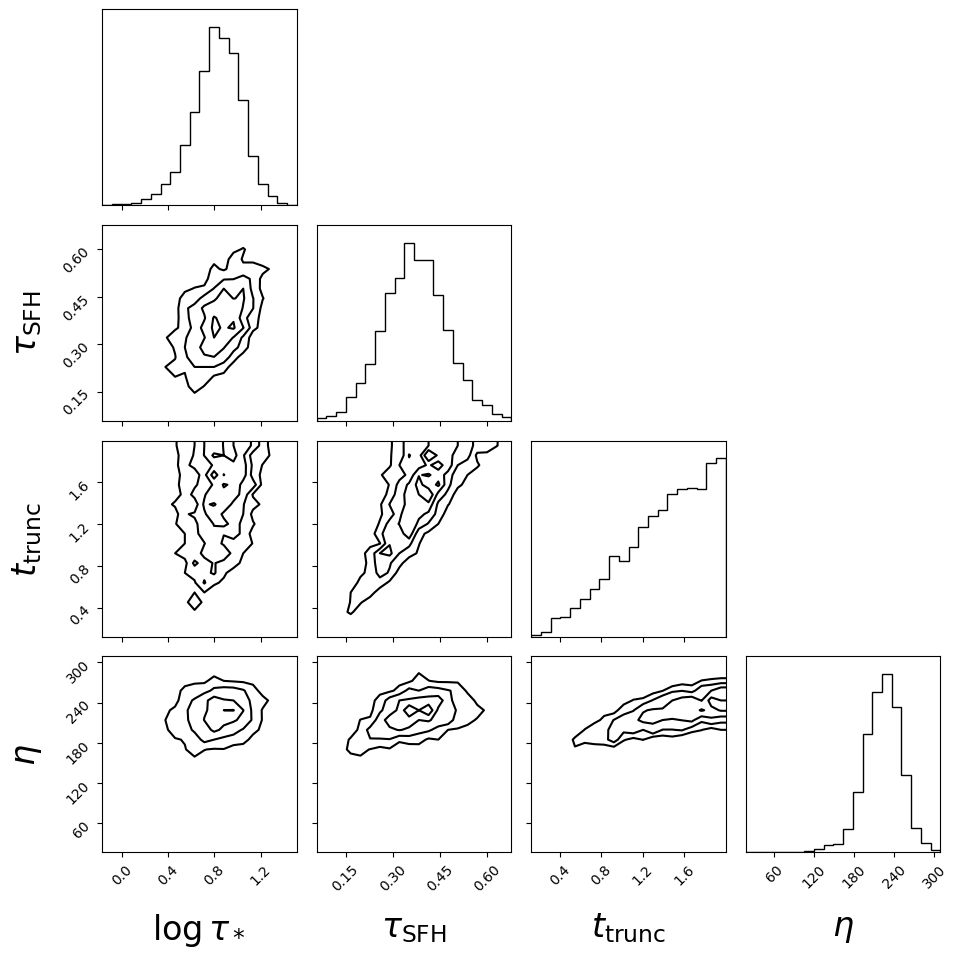

In [16]:
# Posterior Corner Plot
fig = corner(
    samples,
    labels=[
        r"$\log\tau_*$",
        r"$\tau_{\mathrm{SFH}}$",
        r"$t_{\mathrm{trunc}}$",
        r"$\eta$",
    ],
    plot_datapoints=False,
    plot_density=False,
    color="black",
    hist_kwargs={"histtype": "step", "density": True},
    label_kwargs={"fontsize": 24},
)

plt.tight_layout()
plt.show()

Now let's check how well the WAF2017 model compares to the data using the median posterior values. This is a pretty good fit! Compared to the other models, it predicts an MDF that is both less sharply peaked and less skewed. We can also see it provides a better fit to the low-metallicity end of the CDF than the dealyed accreting box. If we were to perform a more thorough posterior predictive check (i.e., sample multiple realizations from the posterior with realistic uncertainties), we would see that the differences between the data and the model are small relative to the uncertainties and consistent with the posterior distribution. This final example here shows how all of these different aspects of galaxy evolution (star formation efficiency, star formation history, outflows) shape the resulting metallicity distribution of a galaxy.

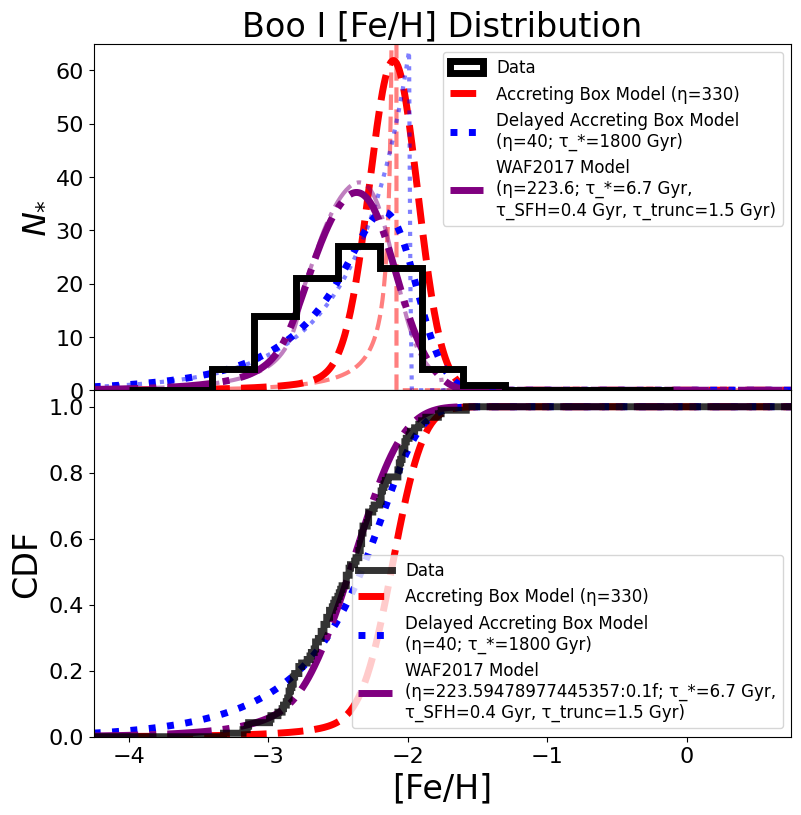

In [17]:
plt.figure(figsize=(9, 9))
gs = GridSpec(2, 1)
gs.update(hspace=0)
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[1, 0], sharex=ax1)

dFeH = 1e-2  # dex
fine_bins = np.arange(-10, 2.0 + dFeH, dFeH)
n_star = boo1_df.shape[0]
dt = 1e-5  # Gyr
t_trunc = 10  # Gyr
t = np.arange(dt, t_trunc + dt, dt)

# WAF2017 Model
SFH_fn = "exponential"  # exponential SFH; SFR ~ exp(-t/tau);
IaDTD_fn = "powerlaw"  # SN Ia delay time distribution; -1.1 Powerlaw DTD (sum of two exponentials); Maoz+ (2012)
tDminIa = 0.05  # Minimum SN Ia Time Delay; Gyr; Maoz+ (2012)
r = 0.4  # Recycling fraction; Kroupa IMF after 1 Gyr
SolarFe = 0.0013  # Iron Solar Scale; Asplund (2009)
SolarAlphaMg = 0.0007  # Magnesium Solar Scale; Asplund (2009)
yFeCC = 0.0006  # Core-collapse SN Iron Yields
yFeIa = 0.0012  # SN Ia Iron Yields Yields
yAlphaMgCC = 0.001  # Core-collapse SN Mg Yields
SolarAlpha = SolarAlphaMg
yAlphaCC = yAlphaMgCC
fRet = fRetCC = fRetIa = 1.0  # Metal Retention Factor; decrease to implement metal-enriched outflows
default_par = DefaultParSet()
default_par.update(
    {
        "SFH_fn": SFH_fn,
        "IaDTD_fn": IaDTD_fn,
        "tDminIa": tDminIa,
        "r": r,
        "dt": dt,
        "SolarAlpha": SolarAlpha,
        "SolarFe": SolarFe,
        "yAlphaCC": yAlphaCC,
        "yFeCC": yFeCC,
        "yFeIa": yFeIa,
        "fRet": fRet,
        "eta": samples["eta"].median(),
        "tauSFE": 10**samples["logtauSFE"].median(),
        "tauSFH": samples["tauSFH"].median(),
        "t_trunc": samples["t_trunc"].median(),
    }
)
sfr, oh, feh, ofe = waf2017(**default_par.model_kwargs)
feh_pdf, grid = get_PDF(
    feh,
    sfr,
    grid=fine_bins,
    lower_bound=-np.inf,
    floor=1e-20,
)
feh_pdf_noerr = feh_pdf.copy()
feh_pdf_noerr *= n_star * 0.3
feh_cdf_noerr = np.cumsum(feh_pdf_noerr) * dFeH / 0.3 / n_star

feh_pdf = gaussian_filter1d(feh_pdf, 0.1 / (grid[1] - grid[0]))
feh_pdf *= n_star * 0.3
feh_cdf = np.cumsum(feh_pdf) * dFeH / 0.3 / n_star


# Accreting Box Model
mdf_accretingbox = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035, 
    e_mh=boo1_df["FeH_err"].median(),
    eta=330,
    Zsolar=0.0013,
)
mdf_accretingbox *= n_star * 0.3
cmdf_accretingbox = np.cumsum(mdf_accretingbox) * dFeH / 0.3 / n_star
# Accreting Box Model (no error)
mdf_accretingbox_noerr = mhdist_accretingbox(
    mhs=fine_bins, 
    p=0.0035,
    e_mh=0.0,
    eta=330,
    Zsolar=0.0013,
)
mdf_accretingbox_noerr *= n_star * 0.3
cmdf_accretingbox_noerr = np.cumsum(mdf_accretingbox_noerr) * dFeH / 0.3 / n_star

# Delayed Accreting Box Model
mdf_delayaccretingbox = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1800,
    solar_Fe=7.5,
    eta=40,
    r=0.4,
    mhs=fine_bins,
    e_mh=boo1_df["FeH_err"].median(),
)
mdf_delayaccretingbox *= n_star * 0.3
cmdf_delayaccretingbox = np.cumsum(mdf_delayaccretingbox) * dFeH / 0.3 / n_star
# Delayed Accreting Box Model (no error)
mdf_delayaccretingbox_noerr = mhdist_delayedaccretingbox(
    t=t,
    p_Fe_Ia=0.0017,
    p_Fe_II=0.0012,
    tau_Ia=0.4,
    tau_Ia_2=3.3,
    mindt=0.05,
    tau_star=1800,
    solar_Fe=7.5,
    eta=40,
    r=0.4,
    mhs=fine_bins,
    e_mh=0.0,
)
mdf_delayaccretingbox_noerr *= n_star * 0.3
cmdf_delayaccretingbox_noerr = np.cumsum(mdf_delayaccretingbox_noerr) * dFeH / 0.3 / n_star

# Plot MDF
# Data
ax1.hist(
    boo1_df["FeH"],
    color="k",
    histtype="step",
    bins=np.arange(-4, 0, 0.3),
    lw=5,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax1.plot(
    fine_bins,
    mdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Accreting Box Model (no error)
ax1.plot(
    fine_bins,
    mdf_accretingbox_noerr,
    c='r',
    lw=3,
    ls='--',
    alpha=0.5,
)
# Delayed Accreting Box Model
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label="Delayed Accreting Box Model\n(η=40; τ_*=1800 Gyr)",
)
# Delayed Accreting Box Model (no error)
ax1.plot(
    fine_bins[1:],
    mdf_delayaccretingbox_noerr,
    c='b',
    lw=3,
    ls=':',
    alpha=0.5,
)
# WAF2017 Model
ax1.plot(
    grid,
    feh_pdf,
    c='purple',
    lw=5,
    ls='-.',
    label=f"WAF2017 Model\n(η={samples['eta'].median():0.1f}; τ_*={10**samples['logtauSFE'].median():0.1f} Gyr,\nτ_SFH={samples['tauSFH'].median():0.1f} Gyr, τ_trunc={samples['t_trunc'].median():0.1f} Gyr)",
)
# WAF2017 Model (no error)
ax1.plot(
    grid,
    feh_pdf_noerr,
    c='purple',
    lw=3,
    ls='-.',
    alpha=0.5,
)


# Plot CMDF
# Data 
counts, bin_edges = np.histogram(
    boo1_df["FeH"], bins=fine_bins, density=True
)
dx = bin_edges[1] - bin_edges[0]
cdf = np.cumsum(counts * dx)
ax2.stairs(
    cdf,
    fine_bins,
    color="k",
    lw=5,
    ls="-",
    alpha=0.8,
    label="Data",
    zorder=100,
)
# Accreting Box Model
ax2.plot(
    fine_bins,
    cmdf_accretingbox,
    c='r',
    lw=5,
    ls='--',
    label="Accreting Box Model (η=330)",
)
# Delayed Accreting Box Model
ax2.plot(
    fine_bins[1:],
    cmdf_delayaccretingbox,
    c='b',
    lw=5,
    ls=':',
    label="Delayed Accreting Box Model\n(η=40; τ_*=1800 Gyr)",
)
# WAF2017 Model
ax2.plot(
    grid,
    feh_cdf,
    c='purple',
    lw=5,
    ls='-.',
    label=f"WAF2017 Model\n(η={samples['eta'].median()}:0.1f; τ_*={10**samples['logtauSFE'].median():0.1f} Gyr,\nτ_SFH={samples['tauSFH'].median():0.1f} Gyr, τ_trunc={samples['t_trunc'].median():0.1f} Gyr)",
)

ax1.set_title("Boo I [Fe/H] Distribution", fontsize=24)
ax1.set_ylabel(r"$N_{*}$", fontsize=24)
ax2.set_xlabel("[Fe/H]", fontsize=24)
ax2.set_ylabel(r"CDF", fontsize=24)
ax1.set_xlim(-4.25, 0.75)
ax1.set_ylim(0, 65)
ax2.set_ylim(0, 1.05)
ax1.tick_params("x", labelsize=0)
ax1.tick_params("y", labelsize=16)
ax2.tick_params("both", labelsize=16)
ax1.legend(fontsize=12, loc="upper right")
ax2.legend(fontsize=12, loc="lower right")
    
plt.show()

## Comparison to Other Galaxies

As a final part of this analysis, let's see how the mass-loading factor and star formation efficiency timescale that we infer for Boo I compares to other galaxies. To do this, we will plot our values alongside literature values as a function of stellar mass. In the following figure of mass-loading factor vs. stellar mass, we include several samples of galaxies for which the mass-loading factor was directly measured by detecting and quantifying galactic winds (black markers; Heckman et al. 2015, Chisholm et al. 2017, and McQuinn et al. 2019). We also include the mass-loading factors of individual galaxies (or a collection of galaxies in the case of Kado-Fong et al. 2024) that were inferred through chemical evolution studies similar to the one just performed (colored markers; see figure for references). We can see a clear trend with stellar mass, and as expected, smaller galaxies have much stronger galactic outflows. This mass-dependence on galactic outflows is the primary reason behind the observed mass-metallicity relationship of galaxies (with more massive galaxies being more metal-rich). This trend is also in reasonable agreement with the predictions of FIRE-2 hydrodynamic simulations extrapolated down to lower masses (Pandya et al. 2021)


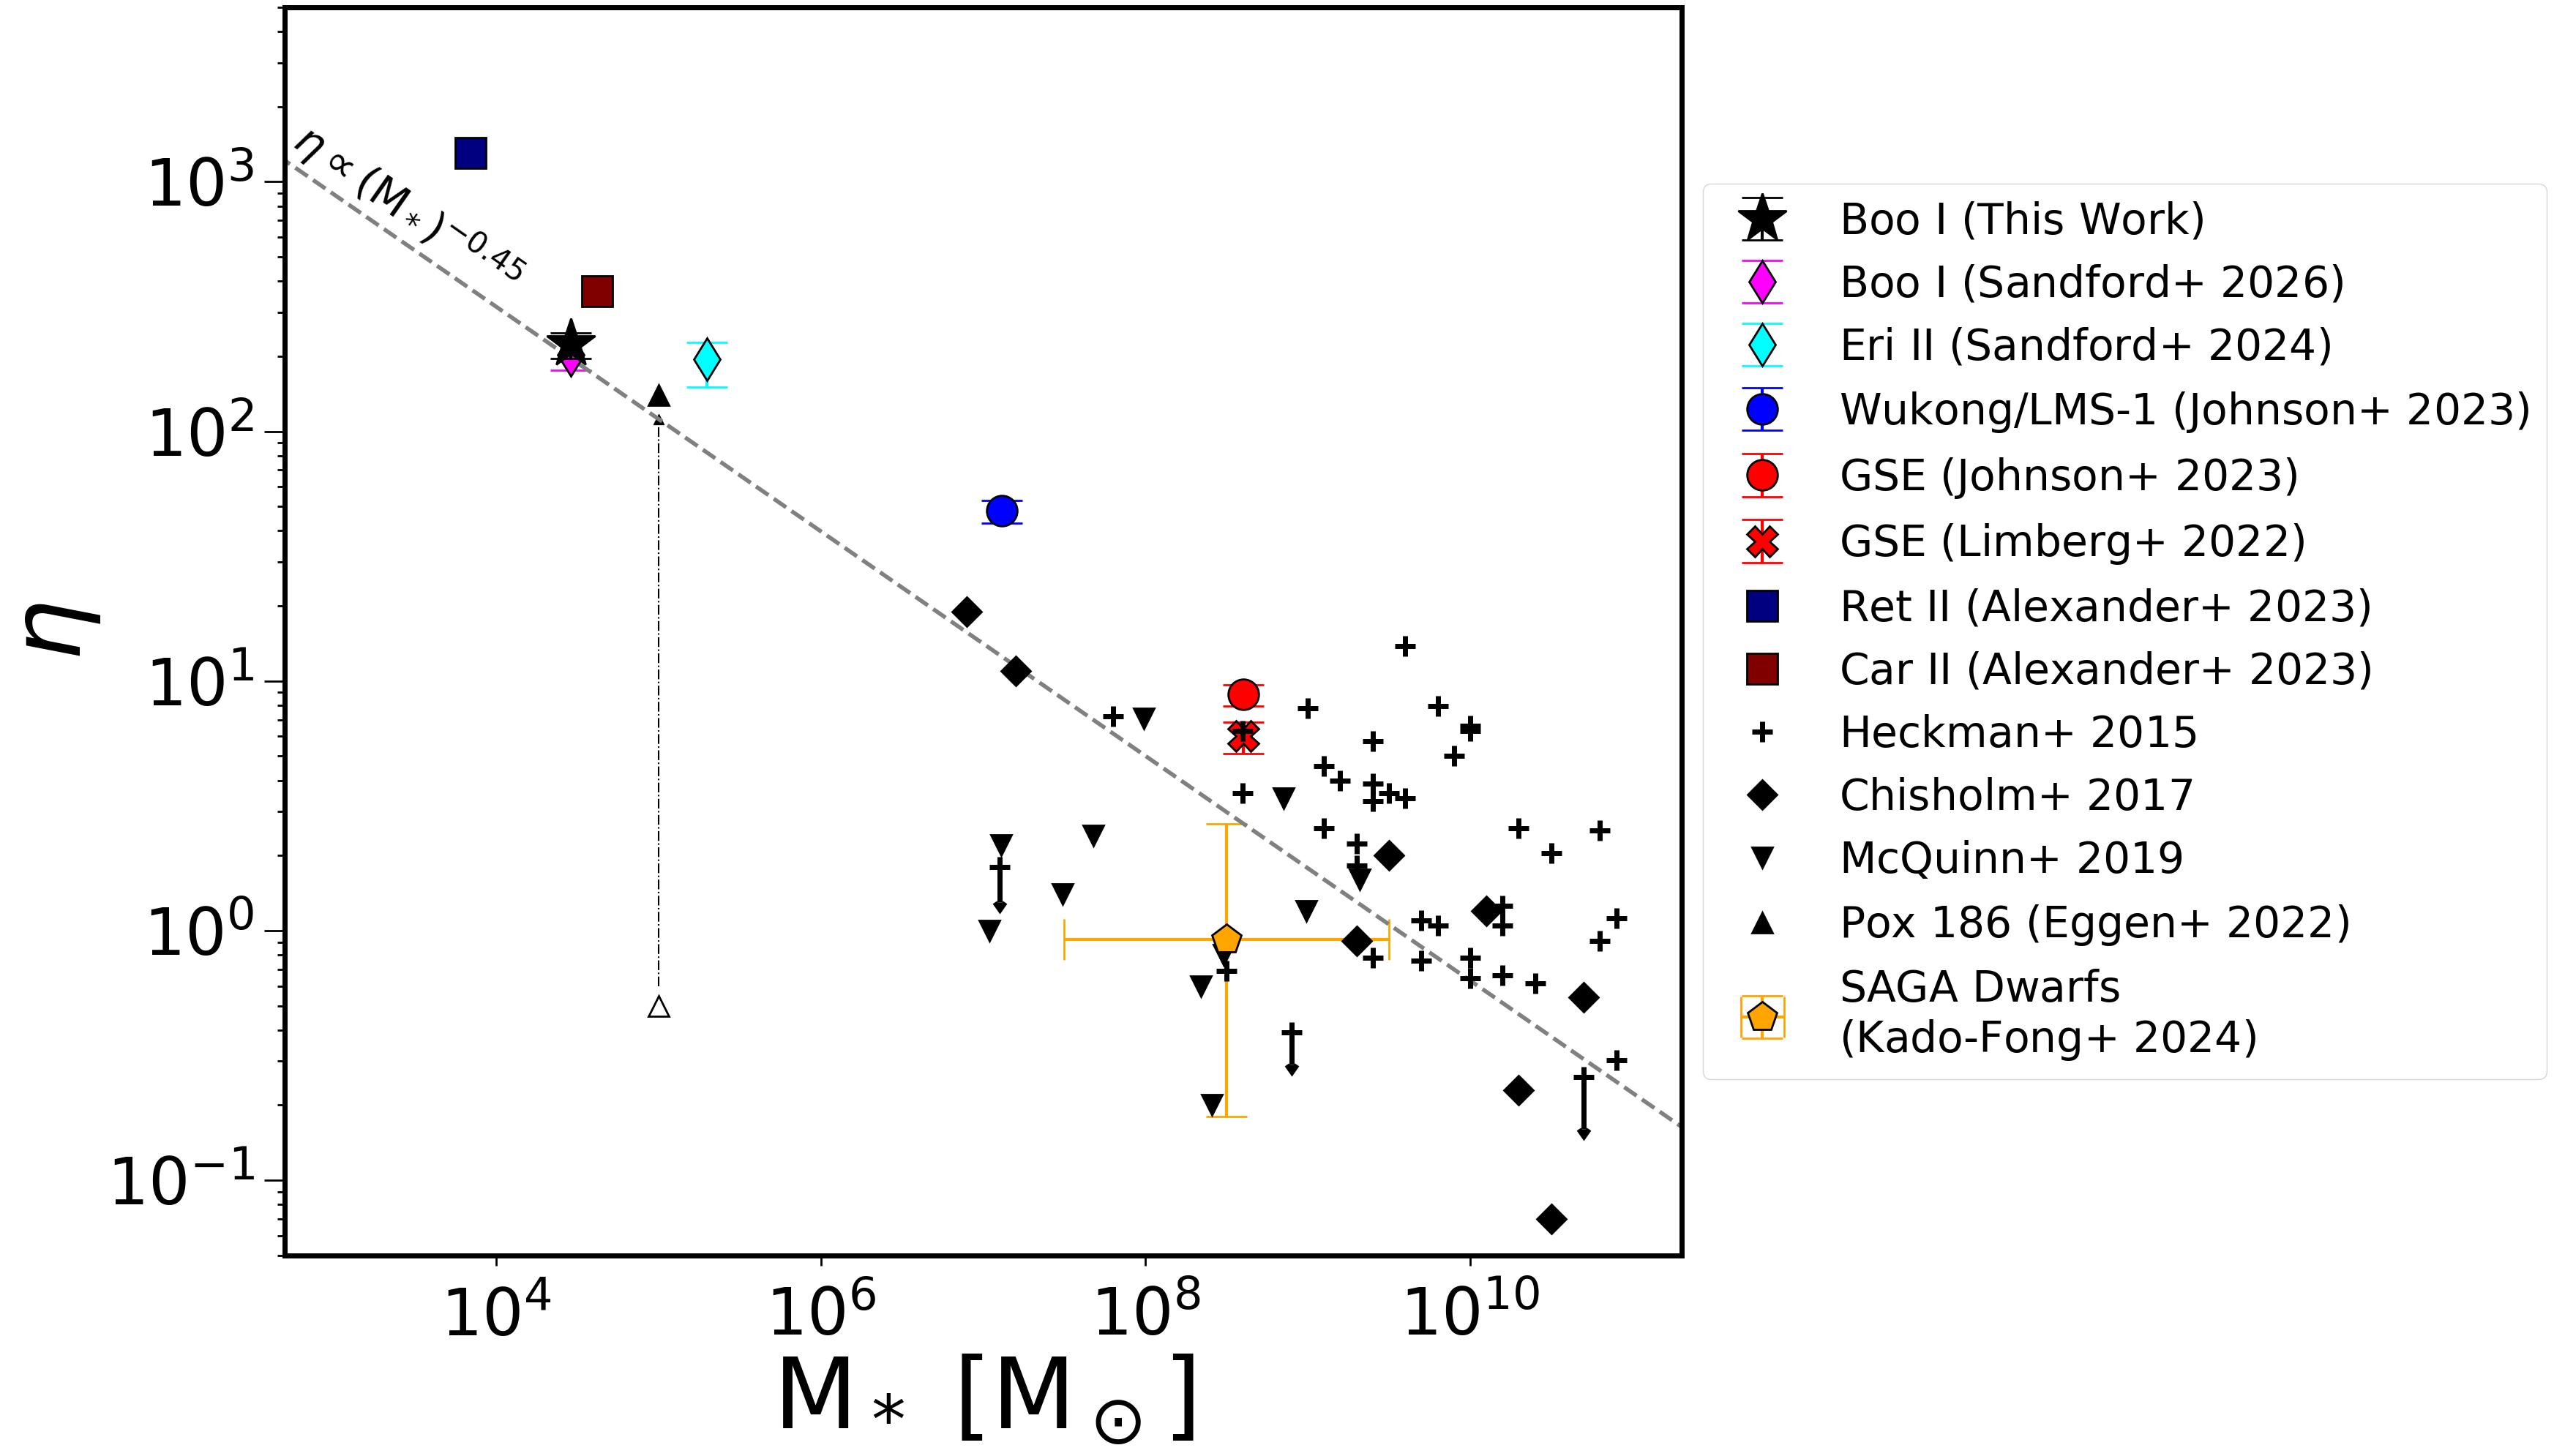

In [18]:
x = np.logspace(2, 12, 100)

# Plot MDF
plt.figure(figsize=(35, 20))
gs = GridSpec(1, 1)
gs.update(hspace=0.0, wspace=0.0)
ax1 = plt.subplot(gs[0, 0])

lower_eta, median_eta, upper_eta = np.percentile(
    samples["eta"], q=[16, 50, 84]
)
# Boo I (Combined; Old Yields)
ax1.errorbar(
    [0.029e6],
    [median_eta],
    yerr=np.array(
        [[median_eta - lower_eta, upper_eta - median_eta]]
    ).T,
    c="k",
    marker="*",
    ms=50,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    zorder=100,
    label=r"$\mathrm{Boo~I}$ " + r"$\mathrm{(This~Work)}$",
)

# Sandford+ 2026 (Boo I)
ax1.errorbar(
    [0.029e6],
    [203],
    yerr=np.array([[27, 36]]).T,
    c="magenta",
    marker="d",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Boo~I}$ " + r"$\mathrm{(Sandford}$+ $2026)$",
)


# Sandford+ 2024 (Eri II)
ax1.errorbar(
    [2e5],
    [194],
    yerr=np.array([[43, 33]]).T,
    c="cyan",
    marker="d",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Eri~II}$ " + r"$\mathrm{(Sandford}$+ $2024)$",
)

# Johnson+ 2022 (Wokong/LMS-1, GSE)
ax1.errorbar(
    [1.3e7],
    [47.99],
    yerr=np.array([[4.98, 4.76]]).T,
    c="b",
    marker="o",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Wukong/LMS}$-1 " + r"$\mathrm{(Johnson}$+ $2023)$",
)
ax1.errorbar(
    [4e8],
    [8.84],
    yerr=np.array([[0.89, 0.83]]).T,
    c="r",
    marker="o",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{GSE}$ " + r"$\mathrm{(Johnson}$+ $2023)$",
)
# Limberg+ 2022 (GSE)
ax1.errorbar(
    [4e8],
    [6],
    yerr=np.array([[0.89, 0.83]]).T,
    c="r",
    marker="X",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{GSE}$ " + r"$\mathrm{(Limberg}$+ $2022)$",
)
# Alexander+ 2023 (Ret II, Car II)
ax1.errorbar(
    [7.0e3],
    [1304],
    c="navy",
    marker="s",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Ret~II}$ " + r"$\mathrm{(Alexander}$+ $2023)$",
)
ax1.errorbar(
    [4.2e4],
    [364],
    c="maroon",
    marker="s",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Car~II}$ " + r"$\mathrm{(Alexander}$+ $2023)$",
)
# Heckman+ 2015
ax1.errorbar(
    10
    ** np.array(
        [
            9.3,
            9.7,
            10.3,
            10.5,
            9.8,
            8.6,
            10.8,
            9.1,
            9.4,
            9.2,
            10.2,
            9.6,
            9.9,
            8.5,
            10.0,
            9.6,
            9.4,
            9.5,
            9.4,
            10.0,
            10.9,
            10.2,
            10.8,
            9.4,
            7.8,
            10.0,
            8.6,
            9.7,
            9.8,
            10.9,
            9.0,
            10.4,
            9.3,
            9.1,
            10.0,
            10.2,
        ]
    ),
    10
    ** np.array(
        [
            0.35,
            0.04,
            0.41,
            0.31,
            0.02,
            0.55,
            0.40,
            0.66,
            0.52,
            0.60,
            0.02,
            1.14,
            0.70,
            -0.16,
            -0.19,
            0.53,
            -0.11,
            0.55,
            0.59,
            -0.11,
            0.05,
            0.10,
            -0.04,
            0.76,
            0.86,
            0.82,
            0.80,
            -0.12,
            0.90,
            -0.52,
            0.89,
            -0.21,
            0.26,
            0.41,
            0.80,
            -0.18,
        ],
    ),
    c="k",
    marker="+",
    ms=20,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=5,
    label=r"$\mathrm{Heckman}$+ $2015$",
)
ax1.errorbar(
    10 ** np.array([7.1, 8.9, 10.7]),
    [1.80, 0.39, 0.26],
    yerr=[0.5, 0.1, 0.1],
    uplims=[True, True, True],
    c="k",
    marker="+",
    ms=20,
    capsize=5,
    lw=5,
    ls="",
    mec="k",
    mew=5,
)
# Chisholm+ 2017
ax1.errorbar(
    10 ** np.array([6.9, 7.2, 9.3, 9.5, 10.1, 10.3, 10.5, 10.7]),
    [19, 11, 0.91, 2.0, 1.2, 0.23, 0.07, 0.54],
    c="k",
    marker="D",
    ms=20,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Chisholm}$+ $2017$",
)
# McQuinn+ 2019
ax1.errorbar(
    10 ** np.array([7.11, 7.04, 7.99, 7.68, 7.49, 8.34, 8.41, 8.48, 8.99, 8.85, 9.32]),
    [2.2, 1.0, 7.1, 2.4, 1.4, 0.6, 0.2, 0.8, 1.2, 3.4, 1.6],
    c="k",
    marker="v",
    ms=20,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{McQuinn}$+ $2019$",
)
# Eggen+ 2022 (Pox)
ax1.errorbar(
    10 ** np.array([5]),
    [0.5],
    c="white",
    marker="^",
    ms=20,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
)
ax1.plot([1e5, 1e5], [0.60, 112], ls="-.", c="k")
ax1.scatter(1e5, 112, marker="^", s=100, c="k")
ax1.errorbar(
    10 ** np.array([5]),
    [140],
    c="k",
    marker="^",
    ms=20,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Pox~186}$ " + r"$\mathrm{(Eggen}$+ $2022)$",
)
# Kado-Fong+ 2024 (SAGA Dwarfs)
ax1.errorbar(
    [10**8.5],
    [0.92],
    xerr=np.array([[10**8.5 - 10**7.5, 10**9.5 - 10**8.5]]).T,
    yerr=np.array([[0.74, 1.76]]).T,
    # c="b",
    c="orange",
    marker="p",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    # label=r"$\mathrm{Wukong/LMS}$-1 " + r"$\mathrm{(Johnson}$+ $2022)$",
    label=r"$\mathrm{SAGA~Dwarfs}$ "
    + "\n"
    + r"$\mathrm{(Kado}$-$\mathrm{Fong}$+ $2024)$",
)
# FIRE-2
ax1.plot(
    x,
    10**4.3 * (x) ** (-0.45),
    ls="--",
    lw=4,
    c="grey",
    # label=r"$\mathrm{FIRE}$-$2$ " + "\n" + r"$\mathrm{(Pandya}$+ $2021)$",
)
ax1.text(5e2, 3.5e2, r"$\eta\propto(\mathrm{M}_*)^{-0.45}$", fontsize=42, rotation=-35)

ax1.set_xlabel(r"$\mathrm{M}_*~[\mathrm{M}_\odot]$", fontsize=96)
ax1.set_ylabel(r"$\eta$", fontsize=96)
ax1.tick_params("x", labelsize=64, length=10, width=2, pad=20)
ax1.tick_params("y", labelsize=64, length=20, width=2, pad=10)
ax1.set_xlim(0.5e3, 2e11)
ax1.set_ylim(5e-2, 5e3)
ax1.set_xscale("log")
ax1.set_yscale("log")
[x.set_linewidth(5) for x in ax1.spines.values()]
ax1.tick_params(axis="both", which="minor", length=7.5, width=2)
ax1.tick_params(axis="x", which="minor", length=7.5, width=2)
ax1.legend(fontsize=42, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

Below is a similar figure for the star formation efficiency (recall that $\tau_\star = \mathrm{SFE}^{-1}$). Though there is more scatter, there is still a clear trend with lower mass galaxies having lower star formation efficiencies. Our inferred value for Boo I is maybe a little higher than expected (and reported previously by Vincenzo et al. 2014 and Lacchin et al. 2020), but it's within the scatter of this distribution (and consistent within the uncertainties of the value reported previously by Romano et al. 2015). Adopting a linear-exponential star formation history alleviates this tension slightly.

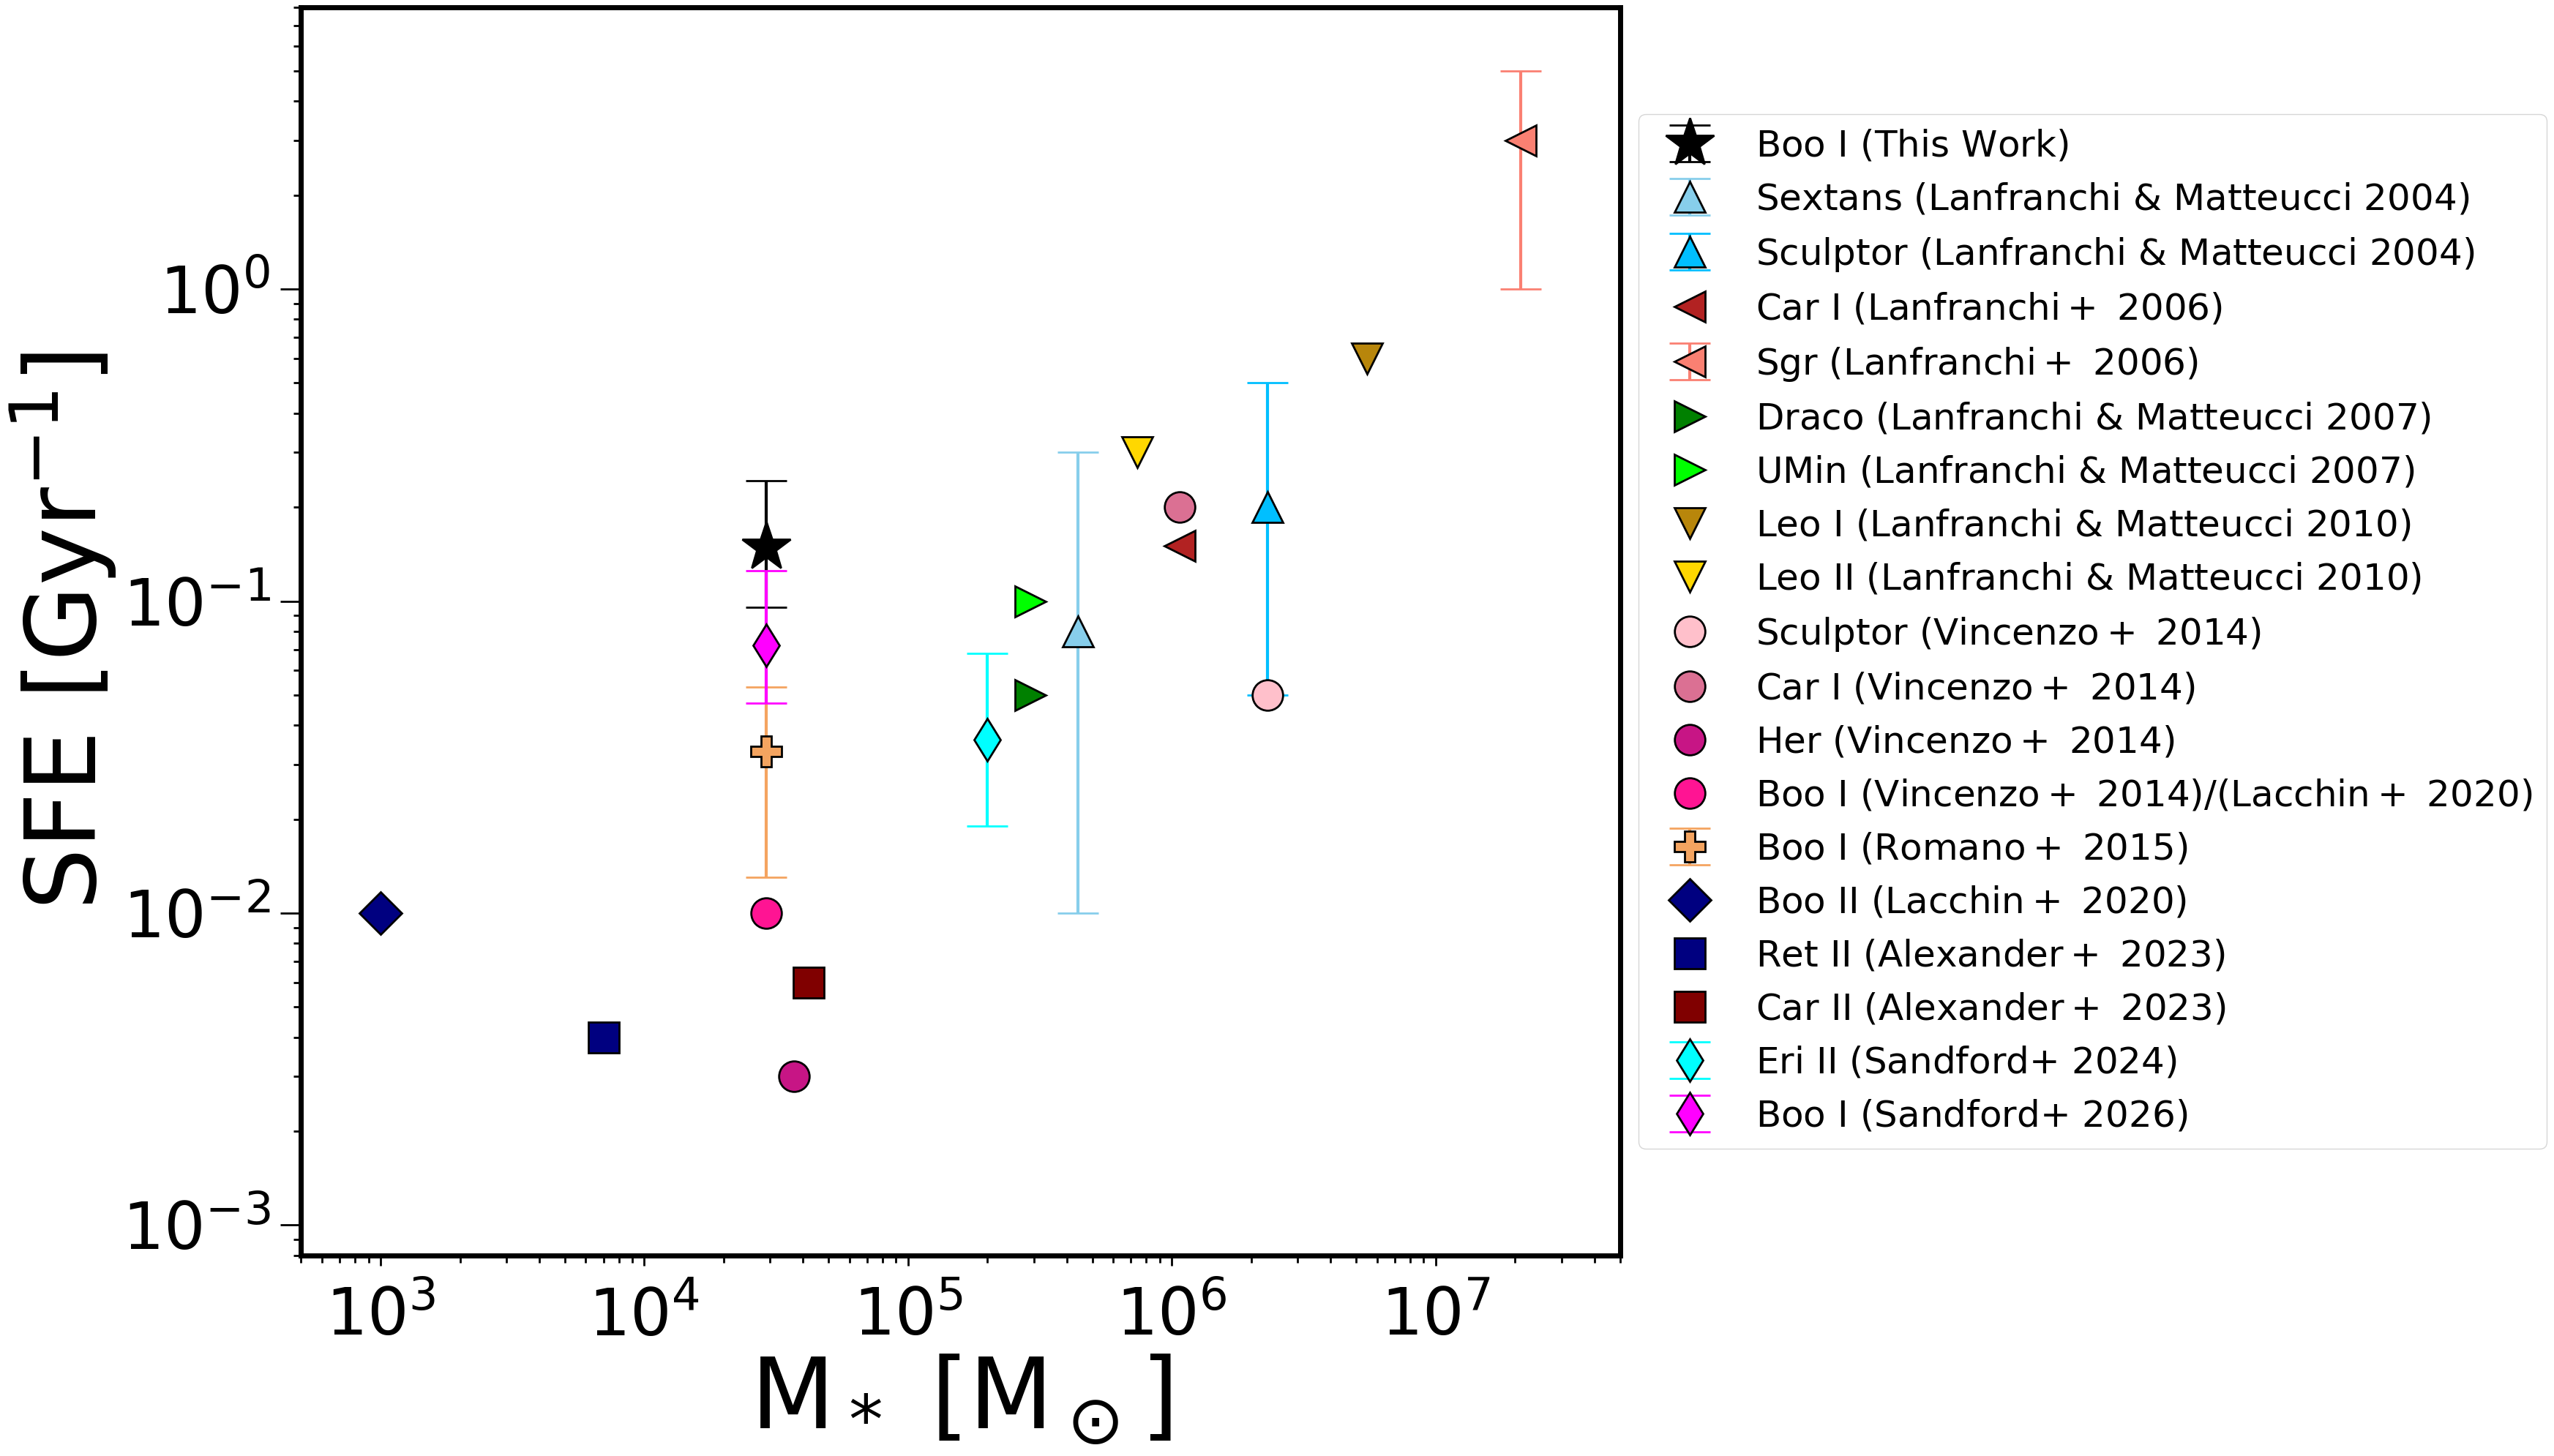

In [19]:
x = np.logspace(2, 12, 100)

# Plot MDF
plt.figure(figsize=(35, 20))
gs = GridSpec(1, 1)
gs.update(hspace=0.0, wspace=0.0)
ax1 = plt.subplot(gs[0, 0])

lower_sfe, median_sfe, upper_sfe = np.percentile(
    10 ** (-samples["logtauSFE"]), q=[16, 50, 84]
)
# Boo I (Combined; Old Yields)
ax1.errorbar(
    [0.029e6],
    [median_sfe],
    yerr=np.array(
        [[median_sfe - lower_sfe, upper_sfe - median_sfe]]
    ).T,
    c="k",
    marker="*",
    ms=50,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Boo~I~(This~Work)}$",
)

# Lanfranchi & Matteucci (2004)
# Lanfranchi & Matteucci (2004) - Draco
# ax1.errorbar(
#     [0.29e6],
#     0.03],
#     yerr=np.array([[0.03-0.005, 0.1-0.03]]).T,
#     c='b',
#     marker='o',
#     ms=20,
#     capsize=10,
#     lw=3,
#     ls='',
#      mec='k',
#     mew=2,
#     label=r'$\mathrm{Draco}$ '+r'$\mathrm{(Lanfranchi~&~Matteucci}$ $2004)$'
# )
# Lanfranchi & Matteucci (2004) - Sextans
ax1.errorbar(
    [0.44e6],
    [0.08],
    yerr=np.array([[0.08 - 0.01, 0.3 - 0.08]]).T,
    c="skyblue",
    marker="^",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Sextans}$ " + r"$\mathrm{(Lanfranchi~&~Matteucci}$ $2004)$",
)
# Lanfranchi & Matteucci (2004) - Sculptor
ax1.errorbar(
    [2.3e6],
    [0.2],
    yerr=np.array([[0.2 - 0.05, 0.5 - 0.2]]).T,
    c="deepskyblue",
    marker="^",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Sculptor}$ " + r"$\mathrm{(Lanfranchi~&~Matteucci}$ $2004)$",
)
# Lanfranchi & Matteucci (2004) - Ursa Minor
# ax1.errorbar(
#     [0.29e6],
#     [0.2],
#     yerr=np.array([[0.2-0.05, 0.5-0.2]]).T,
#     c='b',
#     marker='o',
#     ms=20,
#     capsize=10,
#     lw=3,
#     ls='',
#     mec='k',
#     mew=2,
#     label=r'$\mathrm{Ursa~Minor}$ '+r'$\mathrm{(Lanfranchi~&~Matteucci}$ $2004)$'
# )
# Lanfranchi & Matteucci (2004) - Carina
# ax1.errorbar(
#     [1.07e6],
#     [0.1],
#     yerr=np.array([[0.1-0.02, 0.4-0.1]]).T,
#     c='b',
#     marker='o',
#     ms=20,
#     capsize=10,
#     lw=3,
#     ls='',
#     mec='k',
#     mew=2,
#     label=r'$\mathrm{Carina}$ '+r'$\mathrm{(Lanfranchi~&~Matteucci}$ $2004)$'
# )
# Lanfranchi & Matteucci (2004) - Sagittarius
# ax1.errorbar(
#     [21e6],
#     [3],
#     yerr=np.array([[3-1, 5-3]]).T,
#     c='b',
#     marker='o',
#     ms=20,
#     capsize=10,
#     lw=3,
#     ls='',
#     mec='k',
#     mew=2,
#     label=r'$\mathrm{Sagittarius}$ '+r'$\mathrm{(Lanfranchi~and~Matteucci}$ $2004)$'
# )

# Lanfranchi+ (2006)
# Lanfranchi & Matteucci (2006) - Carina
ax1.errorbar(
    [1.07e6],
    [0.15],
    c="firebrick",
    marker="<",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Car~I}$ " + r"$\mathrm{(Lanfranchi}+$ $2006)$",
)
# Lanfranchi & Matteucci (2006) - Sagittarius
ax1.errorbar(
    [21e6],
    [3],
    yerr=np.array([[3 - 1, 5 - 3]]).T,
    c="salmon",
    marker="<",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Sgr}$ " + r"$\mathrm{(Lanfranchi}+$ $2006)$",
)

# Lanfranchi & Matteucci (2007)
# Lanfranchi & Matteucci (2007) - Draco
ax1.errorbar(
    [0.29e6],
    [0.05],
    c="green",
    marker=">",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Draco}$ " + r"$\mathrm{(Lanfranchi~&~Matteucci}$ $2007)$",
)
# Lanfranchi & Matteucci (2007) - Ursa Minor
ax1.errorbar(
    [0.29e6],
    [0.1],
    c="lime",
    marker=">",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{UMin}$ " + r"$\mathrm{(Lanfranchi~&~Matteucci}$ $2007)$",
)

# Lanfranchi & Matteucci (2010)
# Lanfranchi & Matteucci (2010) - Leo I
ax1.errorbar(
    [5.5e6],
    [0.6],
    c="darkgoldenrod",
    marker="v",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Leo~I}$ " + r"$\mathrm{(Lanfranchi~&~Matteucci}$ $2010)$",
)
# Lanfranchi & Matteucci (2010) - Leo II
ax1.errorbar(
    [0.74e6],
    [0.3],
    c="gold",
    marker="v",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Leo~II}$ " + r"$\mathrm{(Lanfranchi~&~Matteucci}$ $2010)$",
)

# Vincent+ (2014)
# Vincent+ (2014) - Sculptor
ax1.errorbar(
    [2.3e6],
    [0.05],
    c="pink",
    marker="o",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Sculptor}$ " + r"$\mathrm{(Vincenzo}+$ $2014)$",
)
# Vincent+ (2014) - Carina
ax1.errorbar(
    [1.07e6],
    [0.2],
    c="palevioletred",
    marker="o",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Car~I}$ " + r"$\mathrm{(Vincenzo}+$ $2014)$",
)
# Vincent+ (2014) - Hercules
ax1.errorbar(
    [0.037e6],
    [0.003],
    c="mediumvioletred",
    marker="o",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Her}$ " + r"$\mathrm{(Vincenzo}+$ $2014)$",
)
# Vincent+ (2014) - Bootes I
ax1.errorbar(
    [0.029e6],
    [0.01],
    c="deeppink",
    marker="o",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Boo~I}$ "
    + r"$\mathrm{(Vincenzo}+$ $2014)$/$\mathrm{(Lacchin}+$ $2020)$",
)

# Romano+ (2015)
# Romano+ (2015) - Boo I
ax1.errorbar(
    [0.029e6],
    [0.033],
    yerr=np.array([[0.033 - 0.013, 0.053 - 0.033]]).T,
    c="sandybrown",
    marker="P",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Boo~I}$ " + r"$\mathrm{(Romano}+$ $2015)$",
)

# Lacchin+ (2020)
# Lacchin+ (2020) - Boo I
# ax1.errorbar(
#    [0.029e6],
#    [0.01],
#    c="g",
#    marker="D",
#    ms=20,
#    capsize=10,
#    lw=3,
#    ls="",
#    mec="k",
#    mew=2,
#    label=r"$\mathrm{Bo\"otes~I}$ "   r"r"$\mathrm{(Lacchin}+$ $2020",$",
# )
# Lacchin+ (2020) - Boo II
ax1.errorbar(
    [0.001e6],
    [0.01],
    c="navy",
    marker="D",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Boo~II}$ " + r"$\mathrm{(Lacchin}+$ $2020)$",
)

# Johnson+ (2022)
# Johnson+ (2022) - Wukong/LMS-1
# ax1.errorbar(
#    [1.3e7],
#    [1 / 44.97],
#    yerr=np.array(
#        [[1 / 44.97 - 1 / (44.97 + 7.85), 1 / (44.97 - 6.77) - 1 / 44.97]]
#    ).T,
#    c="b",
#    marker="o",
#    ms=20,
#    capsize=10,
#    lw=3,
#    ls="",
#    mec="k",
#    mew=2,
#    label=r"$\mathrm{Wukong/LMS}$-1 " + r"$\mathrm{(Johnson}$+ $2022)$",
# )
# ax1.errorbar(
#    [4e8],
#    [1 / 16.08],
#    yerr=np.array(
#        [[1 / 16.08 - 1 / (16.08 + 1.33), 1 / (16.08 - 1.26) - 1 / 16.08]]
#    ).T,
#    c="r",
#    marker="o",
#    ms=20,
#    capsize=10,
#    lw=3,
#    ls="",
#    mec="k",
#    mew=2,
#    label=r"$\mathrm{GSE}$ " + r"$\mathrm{(Johnson}$+ $2022)$",
# )

# Alexander+ (2023)
# Alexander+ (2023) - Ret II
ax1.errorbar(
    [7.0e3],
    [0.004],
    c="navy",
    marker="s",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Ret~II}$ " + r"$\mathrm{(Alexander}+$ $2023)$",
)
# Alexander+ (2023) - Car II
ax1.errorbar(
    [4.2e4],
    [0.006],
    c="maroon",
    marker="s",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Car~II}$ " + r"$\mathrm{(Alexander}+$ $2023)$",
)

# Sandford+ 2024 (Eri II)
ax1.errorbar(
    [2e5],
    [0.036],
    yerr=np.array([[0.017, 0.032]]).T,
    c="cyan",
    marker="d",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Eri~II}$ " + r"$\mathrm{(Sandford}$+ $2024)$",
)

# Sandford+ 2026 (Boo I)
ax1.errorbar(
    [0.029e6],
    [0.072],
    yerr=np.array([[0.025, 0.053]]).T,
    c="magenta",
    marker="d",
    ms=30,
    capsize=20,
    lw=3,
    ls="",
    mec="k",
    mew=2,
    label=r"$\mathrm{Boo~I}$ " + r"$\mathrm{(Sandford}$+ $2026)$",
)


ax1.set_xlabel(r"$\mathrm{M}_*~[\mathrm{M}_\odot]$", fontsize=96)
ax1.set_ylabel(r"$\mathrm{SFE}~[\mathrm{Gyr}^{-1}]$", fontsize=96)
ax1.tick_params("x", labelsize=64, length=10, width=2, pad=20)
ax1.tick_params("y", labelsize=64, length=20, width=2, pad=10)
ax1.set_xlim(0.5e3, 0.5e8)
ax1.set_ylim(0.8e-3, 0.8e1)
ax1.set_xscale("log")
ax1.set_yscale("log")
[x.set_linewidth(5) for x in ax1.spines.values()]
ax1.tick_params(axis="both", which="minor", length=7.5, width=2)
ax1.tick_params(axis="x", which="minor", length=7.5, width=2)
ax1.legend(fontsize=36, ncol=1, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()